# HAI P1 Boiler Surrogate Model
## Two-Component Architecture: Controller (SP+PV→CV) + Plant (CV→PV)

**Purpose**: Data-driven surrogate model for the P1 boiler process of the HAI testbed.
Enables generation of synthetic normal data and injection of attacks at any point
in the control loop (SP, CV, or PV).

**Architecture**:
- **Controller models** (5 per-loop): Learn the PID mapping SP + PV_feedback → CV
- **Plant model** (1 MIMO): Learn the physical dynamics CV_actual → PV
- **Separation guarantee**: Plant never sees SPs; controller never sees post-override CVs

**Validation gates**:
- Gate 1a/1b: Open-loop NRMSE for controller/plant individually
- Gate 2: MLP upgrade if linear fails
- Gate 3: Closed-loop stability when components are connected

## Cell 1 — Config, Imports, Constants

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
from scipy.stats import ks_2samp, probplot
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
import os
import json
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
import time

warnings.filterwarnings('ignore', category=FutureWarning)

# --- Try importing PyTorch (needed for MLP-NARX if linear fails) ---
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"PyTorch available. Device: {DEVICE}")
except ImportError:
    TORCH_AVAILABLE = False
    DEVICE = None
    print("PyTorch not available. MLP-NARX upgrade will not be possible.")

# ============================================================
# LOOP DEFINITIONS — Single source of truth
# Verified against actual hai-train1.csv columns (87 cols, April 2025)
# ============================================================

@dataclass
class LoopConfig:
    name: str
    sp: str                    # Setpoint column
    cv: str                    # Control variable column
    cv_fb: Optional[str]       # CV feedback (Z signal), None if unavailable
    pv: str                    # Process variable column
    sp_range: Tuple[float, float]  # Documented normal SP operating range
    pv_range: Tuple[float, float]  # Documented PV full-scale range
    description: str = ""

# Column name mappings verified from actual data:
#   x1001_05_SETPOINT_OUT=0.196  → PIT01=0.99-1.26  (PC, units differ but doc confirms)
#   x1002_07_SETPOINT_OUT=342.7  → LIT01=335-350     (LC, tracks ✓)
#   x1002_08_SETPOINT_OUT=981.6  → FT03Z=973-994     (FC, tracks ✓; NOT FT03=234)
#   x1003_18_SETPOINT_OUT=28     → TIT01=30-32        (TC, 2-4°C offset)
#   PP04SP=27.98                 → TIT03=27.0-28.1    (CC, tracks ✓)
#   x1003_10_SETPOINT_OUT=3136-3186 → FT02Z=3136-3186 (TC inner cascade, auxiliary)

LOOPS: Dict[str, LoopConfig] = {
    'PC': LoopConfig(
        name='Pressure Control',
        sp='x1001_05_SETPOINT_OUT', cv='P1_PCV01D', cv_fb='P1_PCV01Z',
        pv='P1_PIT01',
        sp_range=(0.1, 0.3), pv_range=(0.0, 10.0),
        description='PID → Sat → RateLim → PCV01D/PCV02D → PIT01'
    ),
    'LC': LoopConfig(
        name='Level Control',
        sp='x1002_07_SETPOINT_OUT', cv='P1_LCV01D', cv_fb='P1_LCV01Z',
        pv='P1_LIT01',
        sp_range=(300, 500), pv_range=(0.0, 720.0),
        description='PID → LCV01D → LIT01, feedforward from FCV03D'
    ),
    'FC': LoopConfig(
        name='Flow Control',
        sp='x1002_08_SETPOINT_OUT', cv='P1_FCV03D', cv_fb='P1_FCV03Z',
        pv='P1_FT03Z',  # FT03Z, not FT03 — SP=981 tracks FT03Z=973-994
        sp_range=(900, 1100), pv_range=(0.0, 2500.0),
        description='PID → Sat → RateLim → FCV03D → FT03Z'
    ),
    'TC': LoopConfig(
        name='Temperature Control',
        sp='x1003_18_SETPOINT_OUT', cv='P1_FCV01D', cv_fb='P1_FCV01Z',
        pv='P1_TIT01',
        sp_range=(25, 30), pv_range=(0.0, 50.0),
        description='PID → PID (cascade) → FCV01D/FCV02D → TIT01'
    ),
    'CC': LoopConfig(
        name='Cooling Control',
        sp='P1_PP04SP', cv='P1_PP04', cv_fb=None,
        pv='P1_TIT03',
        sp_range=(26, 30), pv_range=(0.0, 50.0),
        description='Activation + Sat → PP04 → TIT03'
    ),
}

CROSS_LOOP_COUPLINGS = {
    'LC_FC': 'LC uses feedforward from FCV03D (FC output)',
    'TC_FC': 'TC cascade: outer PID feeds inner flow PID, shares FCV01D/FCV02D',
    'PC_TC': 'Pressure and temperature are physically coupled through heat exchanger',
    'CC_TC': 'Cooling pump (CC) affects main tank temp, which couples to TC via TIT01/TIT03',
}

# Additional P1 signals useful for cross-loop plant modeling
# Excludes confirmed constants from hai-train1:
#   P1_PIT01_HH=524320 (alarm), P1_SOL01D/03D=524320 (alarm),
#   P1_STSP=1, P1_PP01AD/AR=0, P1_PP01BD/BR=1, P1_PP02D/R=1,
#   P1_FCV02D=15, P1_PCV02D=12 (nearly constant in sample but may vary)
AUXILIARY_SIGNALS = [
    'P1_FCV02D', 'P1_FCV02Z',       # TC secondary valve
    'P1_PCV02D', 'P1_PCV02Z',       # PC secondary valve
    'P1_FT01', 'P1_FT01Z',          # Flow sensor 1
    'P1_FT02', 'P1_FT02Z',          # Flow sensor 2
    'P1_FT03',                       # Flow sensor 3 (raw units, different from FT03Z)
    'P1_PIT02',                      # Pressure sensor 2
    'P1_TIT02',                      # Temperature sensor 2
    'P1_PP04D',                      # Cooling pump on/off demand (binary)
    'x1001_15_ASSIGN_OUT',           # PC intermediate block output
    'x1003_10_SETPOINT_OUT',         # TC inner cascade flow setpoint (tracks FT02Z)
    'x1003_24_SUM_OUT',              # TC cascade sum output
]

def get_all_columns():
    cols = set()
    for loop in LOOPS.values():
        cols.add(loop.sp)
        cols.add(loop.cv)
        if loop.cv_fb: cols.add(loop.cv_fb)
        cols.add(loop.pv)
    cols.update(AUXILIARY_SIGNALS)
    return sorted(cols)

ALL_REQUIRED_COLS = get_all_columns()
SP_COLS = [LOOPS[k].sp for k in LOOPS]
CV_COLS = [LOOPS[k].cv for k in LOOPS]
CV_FB_COLS = [LOOPS[k].cv_fb for k in LOOPS if LOOPS[k].cv_fb is not None]
PV_COLS = [LOOPS[k].pv for k in LOOPS]

@dataclass
class ModelConfig:
    W_controller: int = 30
    W_plant: int = 60
    ridge_alpha: float = 1.0
    mlp_hidden_dims: List[int] = field(default_factory=lambda: [128, 64])
    mlp_lr: float = 1e-3
    mlp_batch_size: int = 1024
    mlp_max_epochs: int = 100
    mlp_patience: int = 10
    rollout_horizon: int = 900
    controller_nrmse_threshold: float = 0.03
    plant_nrmse_threshold_rollout: float = 0.08
    closedloop_nrmse_threshold: float = 0.10

CONFIG = ModelConfig()

print("=" * 60)
print("SURROGATE MODEL CONFIGURATION")
print("=" * 60)
print(f"\nLoops: {len(LOOPS)}")
for k, v in LOOPS.items():
    fb = v.cv_fb or "NONE"
    print(f"  {k}: SP={v.sp}, CV={v.cv}, CV_fb={fb}, PV={v.pv}")
print(f"\nColumns needed: {len(ALL_REQUIRED_COLS)}")
print(f"Auxiliary signals: {len(AUXILIARY_SIGNALS)}")

PyTorch available. Device: cuda
SURROGATE MODEL CONFIGURATION

Loops: 5
  PC: SP=x1001_05_SETPOINT_OUT, CV=P1_PCV01D, CV_fb=P1_PCV01Z, PV=P1_PIT01
  LC: SP=x1002_07_SETPOINT_OUT, CV=P1_LCV01D, CV_fb=P1_LCV01Z, PV=P1_LIT01
  FC: SP=x1002_08_SETPOINT_OUT, CV=P1_FCV03D, CV_fb=P1_FCV03Z, PV=P1_FT03Z
  TC: SP=x1003_18_SETPOINT_OUT, CV=P1_FCV01D, CV_fb=P1_FCV01Z, PV=P1_TIT01
  CC: SP=P1_PP04SP, CV=P1_PP04, CV_fb=NONE, PV=P1_TIT03

Columns needed: 34
Auxiliary signals: 15


## Cell 2 — Data Loading and Splitting

In [28]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/HAI_GNN/data/raw/hai-23.05/'

def load_hai_train(data_dir):
    fitting_frames = []
    for i in range(1, 4):
        path = os.path.join(data_dir, f'hai-train{i}.csv')
        print(f"Loading {path}...")
        df = pd.read_csv(path)
        df['_source_file'] = f'train{i}'
        fitting_frames.append(df)
        print(f"  Shape: {df.shape}")
    val_path = os.path.join(data_dir, 'hai-train4.csv')
    print(f"Loading {val_path}...")
    df_val = pd.read_csv(val_path)
    df_val['_source_file'] = 'train4'
    print(f"  Shape: {df_val.shape}")
    df_fit = pd.concat(fitting_frames, ignore_index=True)
    print(f"\nFitting: {df_fit.shape[0]:,} rows ({df_fit.shape[0]/3600:.1f}h)")
    print(f"Validation: {df_val.shape[0]:,} rows ({df_val.shape[0]/3600:.1f}h)")
    return df_fit, df_val

df_fit_raw, df_val_raw = load_hai_train(DATA_DIR)

# Column verification
available = set(df_fit_raw.columns)
missing = [c for c in ALL_REQUIRED_COLS if c not in available]
if missing:
    print(f"\n⚠ Missing {len(missing)} columns: {missing}")
else:
    print(f"\n✓ All {len(ALL_REQUIRED_COLS)} required columns found.")

keep = ['timestamp', '_source_file'] + [c for c in ALL_REQUIRED_COLS if c in available]
df_fit = df_fit_raw[keep].copy()
df_val = df_val_raw[keep].copy()
del df_fit_raw, df_val_raw

# Filter auxiliaries to available only
AUXILIARY_SIGNALS = [c for c in AUXILIARY_SIGNALS if c in available]

# Drop truly constant columns (full fitting set)
print("\n--- Constant Column Detection ---")
constant_cols = []
for col in [c for c in ALL_REQUIRED_COLS if c in available]:
    if df_fit[col].dtype not in ['float64','float32','int64']:
        continue
    if df_fit[col].std() < 1e-10:
        constant_cols.append(col)
        print(f"  Dropping: {col} = {df_fit[col].iloc[0]}")

AUXILIARY_SIGNALS = [c for c in AUXILIARY_SIGNALS if c not in constant_cols]
print(f"\n  Auxiliary signals after filtering: {len(AUXILIARY_SIGNALS)}")

# Warn if loop signals are constant
for k, loop in LOOPS.items():
    for name, col in [('SP', loop.sp), ('CV', loop.cv), ('PV', loop.pv)]:
        if col in constant_cols:
            print(f"  *** {k} {name} ({col}) is CONSTANT — loop cannot be modeled ***")

# NaN check
data_cols = [c for c in ALL_REQUIRED_COLS if c in available and c not in constant_cols]
nans = df_fit[data_cols].isnull().sum().sum()
print(f"\n{'✓ No NaNs' if nans == 0 else f'⚠ {nans} NaNs found'}")

# SP-PV tracking
print("\n--- SP-PV Tracking ---")
for k, loop in LOOPS.items():
    if loop.sp not in df_fit.columns or loop.pv not in df_fit.columns:
        continue
    sp_m, sp_s = df_fit[loop.sp].mean(), df_fit[loop.sp].std()
    pv_m, pv_s = df_fit[loop.pv].mean(), df_fit[loop.pv].std()
    corr = df_fit[loop.sp].corr(df_fit[loop.pv])
    print(f"  {k}: SP={sp_m:.2f}±{sp_s:.2f}, PV={pv_m:.2f}±{pv_s:.2f}, corr={corr:.3f}")

# Time continuity
print("\n--- Time Continuity ---")
for src in df_fit['_source_file'].unique():
    ts = pd.to_datetime(df_fit.loc[df_fit['_source_file']==src, 'timestamp'])
    gaps = ts.diff().dt.total_seconds().dropna()
    n_gaps = (gaps > 1.5).sum()
    print(f"  {src}: {'✓' if n_gaps==0 else f'⚠ {n_gaps} gaps'}")

print(f"\nMemory: fit={df_fit.memory_usage(deep=True).sum()/1e6:.0f}MB, "
      f"val={df_val.memory_usage(deep=True).sum()/1e6:.0f}MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading /content/drive/MyDrive/HAI_GNN/data/raw/hai-23.05/hai-train1.csv...
  Shape: (280800, 88)
Loading /content/drive/MyDrive/HAI_GNN/data/raw/hai-23.05/hai-train2.csv...
  Shape: (291600, 88)
Loading /content/drive/MyDrive/HAI_GNN/data/raw/hai-23.05/hai-train3.csv...
  Shape: (126000, 88)
Loading /content/drive/MyDrive/HAI_GNN/data/raw/hai-23.05/hai-train4.csv...
  Shape: (198000, 88)

Fitting: 698,400 rows (194.0h)
Validation: 198,000 rows (55.0h)

✓ All 33 required columns found.

--- Constant Column Detection ---

  Auxiliary signals after filtering: 15

✓ No NaNs

--- SP-PV Tracking ---
  PC: SP=1.12±0.11, PV=1.12±0.10, corr=0.577
  LC: SP=347.07±27.41, PV=347.70±28.13, corr=0.975
  FC: SP=999.40±28.40, PV=999.40±28.62, corr=0.990
  TC: SP=26.69±0.80, PV=30.46±1.31, corr=0.361
  CC: SP=27.72±0.31, PV=27.98±1.21, corr=0.211

--- Time Continuity ---
  t

## Cell 3 — Exploratory Analysis

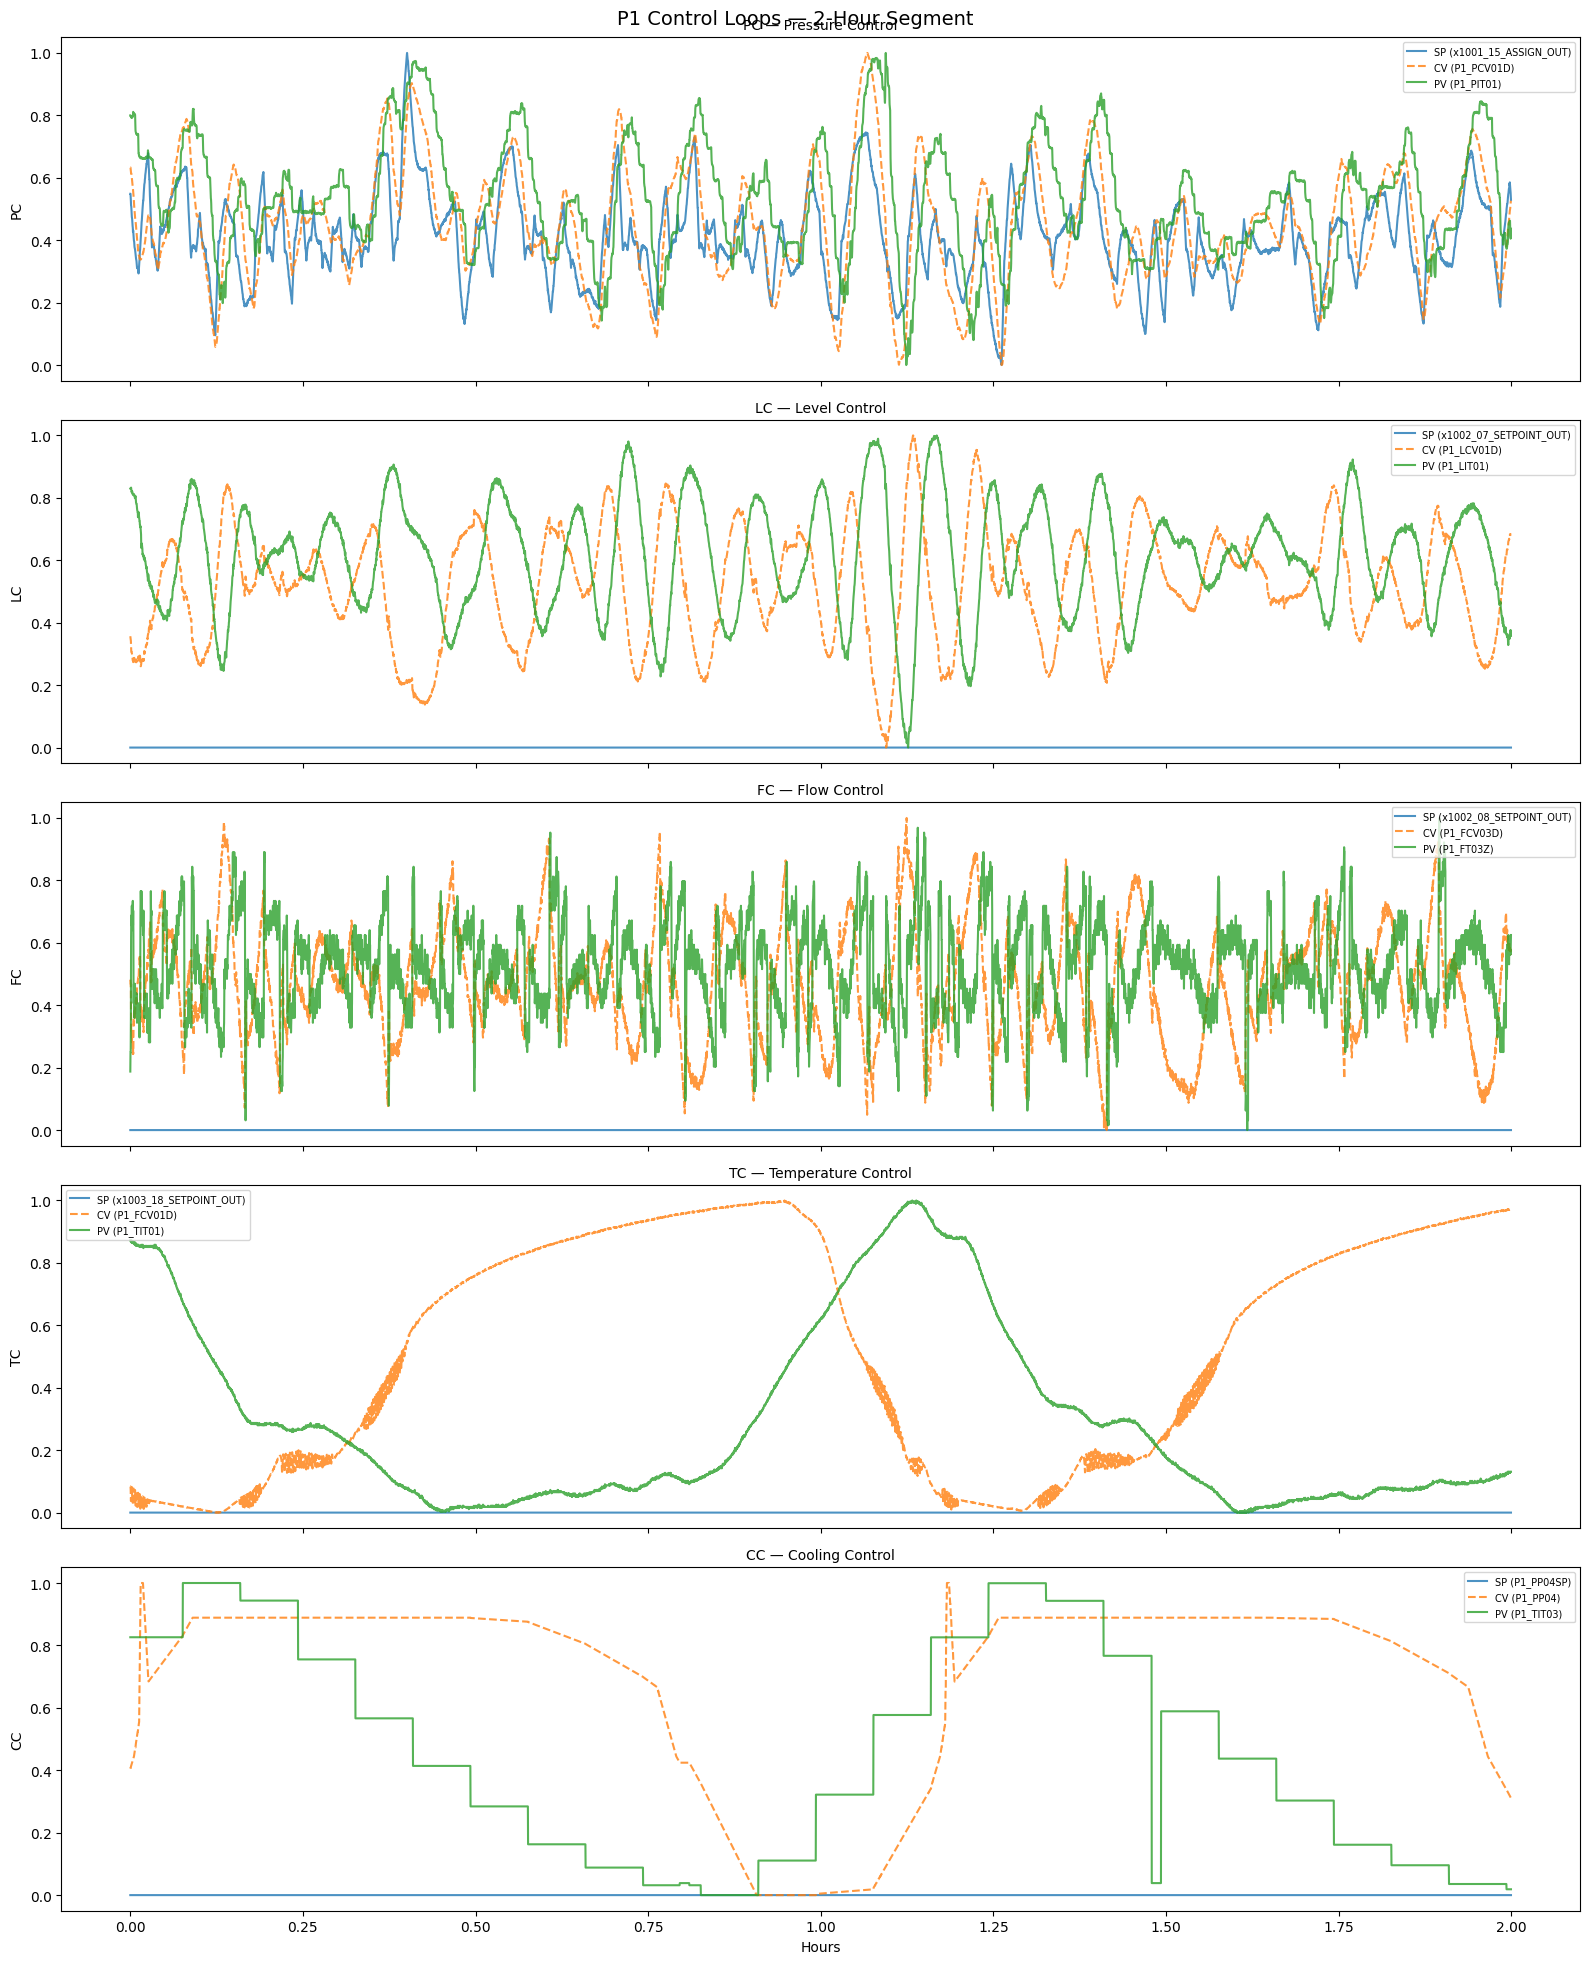

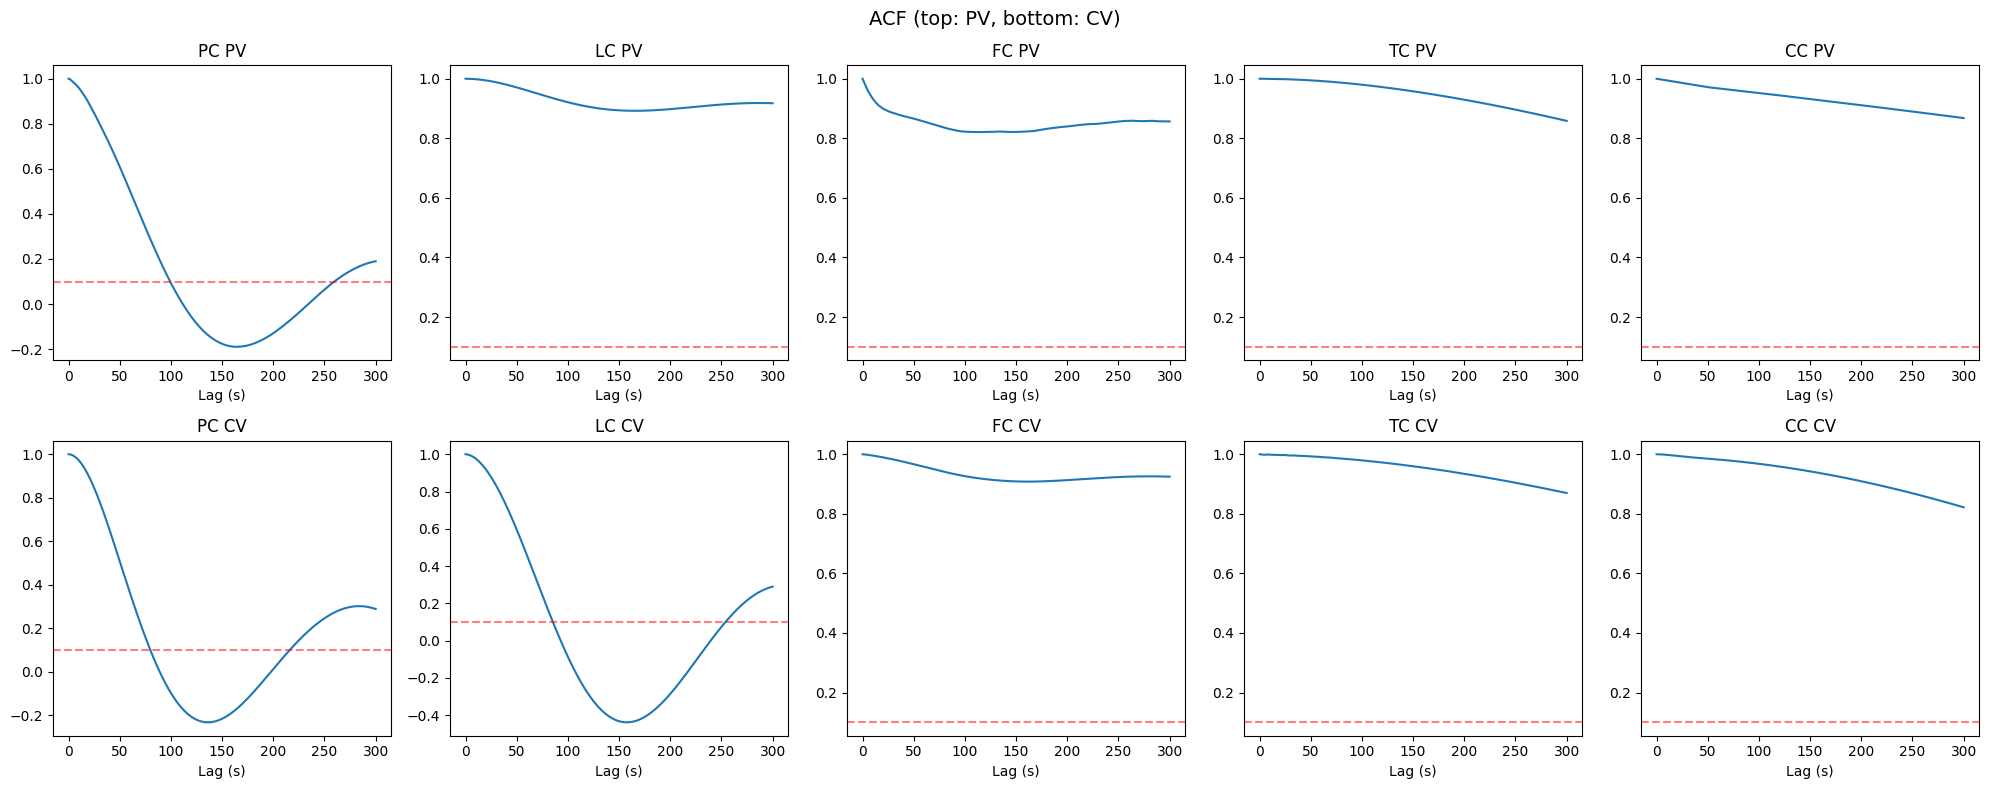

W_plant=120, W_controller=60

Response delays:
  PC: SP→CV=0s, CV→PV=0s
  LC: SP→CV=11s, CV→PV=47s
  FC: SP→CV=0s, CV→PV=120s
  TC: SP→CV=0s, CV→PV=120s
  CC: SP→CV=0s, CV→PV=120s

Setpoint transitions:
  ✓ PC: 55629 (286.7/hr)
  ✓ LC: 680 (3.5/hr)
  ✓ FC: 622 (3.2/hr)
  ✓ TC: 176 (0.9/hr)
  ✓ CC: 67 (0.3/hr)


In [29]:
def compute_acf(x, max_lag=300):
    x = x - np.mean(x)
    n = len(x)
    acf = np.correlate(x, x, mode='full')
    acf = acf[n-1:n-1+max_lag+1]
    return acf / acf[0] if acf[0] != 0 else acf

def compute_ccf(x, y, max_lag=120):
    x = (x - np.mean(x)) / (np.std(x) + 1e-10)
    y = (y - np.mean(y)) / (np.std(y) + 1e-10)
    n = len(x)
    ccf = np.correlate(x, y, mode='full') / n
    lags = np.arange(-n+1, n)
    mask = (lags >= 0) & (lags <= max_lag)
    return lags[mask], ccf[mask]

def count_sp_transitions(sp, threshold_frac=0.01):
    r = sp.max() - sp.min()
    if r < 1e-10: return 0
    return int(np.sum(np.abs(np.diff(sp.values)) > r * threshold_frac))

# 2-hour segment visualization
seg = slice(10000, 17200)
fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=True)
fig.suptitle('P1 Control Loops — 2-Hour Segment', fontsize=14)
for idx, (ln, loop) in enumerate(LOOPS.items()):
    ax = axes[idx]
    t = np.arange(7200) / 3600
    for sig, label, ls in [(loop.sp,'SP','-'), (loop.cv,'CV','--'), (loop.pv,'PV','-')]:
        d = df_fit[sig].iloc[seg].values
        d_n = (d - d.min()) / (d.max() - d.min() + 1e-10)
        ax.plot(t, d_n, label=f'{label} ({sig})', linestyle=ls, alpha=0.8)
    ax.set_ylabel(ln); ax.legend(fontsize=7); ax.set_title(f'{ln} — {loop.name}', fontsize=10)
axes[-1].set_xlabel('Hours')
plt.tight_layout(); plt.show()

# ACF analysis
acf_data = df_fit.iloc[:50000]
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('ACF (top: PV, bottom: CV)', fontsize=14)
pv_decay, cv_decay = {}, {}
for idx, (ln, loop) in enumerate(LOOPS.items()):
    for row, (sig, store) in enumerate([(loop.pv, pv_decay), (loop.cv, cv_decay)]):
        acf = compute_acf(acf_data[sig].values, 300)
        axes[row, idx].plot(acf); axes[row, idx].set_title(f'{ln} {"PV" if row==0 else "CV"}')
        axes[row, idx].axhline(0.1, color='r', linestyle='--', alpha=0.5)
        below = np.where(acf < 0.1)[0]
        store[ln] = below[0] if len(below) > 0 else 300
for ax in axes.flat: ax.set_xlabel('Lag (s)')
plt.tight_layout(); plt.show()

CONFIG.W_plant = min(max(max(pv_decay.values()), 60), 120)
CONFIG.W_controller = min(max(max(cv_decay.values()), 20), 60)
print(f"W_plant={CONFIG.W_plant}, W_controller={CONFIG.W_controller}")

# Cross-correlation delays
print("\nResponse delays:")
for ln, loop in LOOPS.items():
    _, ccf_sc = compute_ccf(acf_data[loop.sp].values, acf_data[loop.cv].values, 120)
    _, ccf_cp = compute_ccf(acf_data[loop.cv].values, acf_data[loop.pv].values, 120)
    print(f"  {ln}: SP→CV={np.argmax(np.abs(ccf_sc))}s, CV→PV={np.argmax(np.abs(ccf_cp))}s")

# Transition counts
print("\nSetpoint transitions:")
for ln, loop in LOOPS.items():
    n = count_sp_transitions(df_fit[loop.sp])
    print(f"  {'✓' if n>50 else '⚠'} {ln}: {n} ({n/(len(df_fit)/3600):.1f}/hr)")

## Cell 4 — Controller Dataset Construction

In [30]:
def build_controller_dataset(df, loop, window):
    cols = [loop.sp, loop.pv]
    if loop.cv_fb: cols.append(loop.cv_fb)
    data = df[cols].values
    target = df[loop.cv].values
    ni = data.shape[1]
    ns = len(data) - window
    X = np.zeros((ns, ni * window), dtype=np.float32)
    for i in range(window):
        X[:, i*ni:(i+1)*ni] = data[i:i+ns]
    return X, target[window:].astype(np.float32), cols

W_c = CONFIG.W_controller
controller_data = {}
print("CONTROLLER DATASETS")
for ln, loop in LOOPS.items():
    Xf, yf, cols = build_controller_dataset(df_fit, loop, W_c)
    Xv, yv, _ = build_controller_dataset(df_val, loop, W_c)
    controller_data[ln] = {'X_fit': Xf, 'y_fit': yf, 'X_val': Xv, 'y_val': yv, 'input_cols': cols}
    print(f"  {ln}: {cols} → {loop.cv}, dim={Xf.shape[1]}, fit={Xf.shape[0]:,}")

CONTROLLER DATASETS
  PC: ['x1001_15_ASSIGN_OUT', 'P1_PIT01', 'P1_PCV01Z'] → P1_PCV01D, dim=180, fit=698,340
  LC: ['x1002_07_SETPOINT_OUT', 'P1_LIT01', 'P1_LCV01Z'] → P1_LCV01D, dim=180, fit=698,340
  FC: ['x1002_08_SETPOINT_OUT', 'P1_FT03Z', 'P1_FCV03Z'] → P1_FCV03D, dim=180, fit=698,340
  TC: ['x1003_18_SETPOINT_OUT', 'P1_TIT01', 'P1_FCV01Z'] → P1_FCV01D, dim=180, fit=698,340
  CC: ['P1_PP04SP', 'P1_TIT03'] → P1_PP04, dim=120, fit=698,340


## Cell 5 — Plant Dataset Construction

In [31]:
def build_plant_dataset(df, cv_cols, pv_cols, aux_cols, window):
    pi_cols = cv_cols + [c for c in aux_cols if c in df.columns]
    data = df[pi_cols].values
    targets = df[pv_cols].values
    ni, ns = data.shape[1], len(data) - window - 1
    X = np.zeros((ns, ni * window), dtype=np.float32)
    for i in range(window):
        X[:, i*ni:(i+1)*ni] = data[i:i+ns]
    pv_cur = targets[window:window+ns].astype(np.float32)
    X = np.hstack([X, pv_cur])
    return X, targets[window+1:window+1+ns].astype(np.float32), pi_cols

W_p = CONFIG.W_plant
plant_aux = [s for s in AUXILIARY_SIGNALS if s not in SP_COLS]
for c in CV_COLS + plant_aux:
    assert c not in SP_COLS, f"LEAKAGE: {c} in plant!"

X_pf, y_pf, plant_input_cols = build_plant_dataset(df_fit, CV_COLS, PV_COLS, plant_aux, W_p)
X_pv, y_pv, _ = build_plant_dataset(df_val, CV_COLS, PV_COLS, plant_aux, W_p)

print(f"PLANT: {len(plant_input_cols)} inputs × {W_p} lags + {len(PV_COLS)} PVs = {X_pf.shape[1]} features")
print(f"  Fit: {X_pf.shape[0]:,}, Val: {X_pv.shape[0]:,}, Mem: {(X_pf.nbytes+X_pv.nbytes)/1e6:.0f}MB")
assert not any(c in SP_COLS for c in plant_input_cols), "SP leaked into plant!"
print("  ✓ No setpoints in plant model")

PLANT: 19 inputs × 120 lags + 5 PVs = 2285 features
  Fit: 698,279, Val: 197,879, Mem: 8191MB
  ✓ No setpoints in plant model


In [32]:
# %% Cell 5b — Subsample plant fitting data to fit in RAM
# Keep all rows near setpoint transitions, subsample steady-state

def smart_subsample(X, y, df_fit, sp_cols, window, stride_steady=5, transition_margin=60):
    """Keep every row near SP transitions, subsample steady state."""
    n = len(df_fit) - window - 1  # same length as X

    # Detect transition timesteps across all SP signals
    is_transition = np.zeros(len(df_fit), dtype=bool)
    for col in sp_cols:
        sp = df_fit[col].values
        r = sp.max() - sp.min()
        if r < 1e-10: continue
        changes = np.where(np.abs(np.diff(sp)) > r * 0.005)[0]
        for c in changes:
            lo = max(0, c - transition_margin)
            hi = min(len(df_fit), c + transition_margin)
            is_transition[lo:hi] = True

    # Map to dataset indices (offset by window)
    is_trans_dataset = is_transition[window + 1:window + 1 + len(X)]

    # Keep all transition rows, subsample steady rows
    trans_idx = np.where(is_trans_dataset)[0]
    steady_idx = np.where(~is_trans_dataset)[0][::stride_steady]
    keep_idx = np.sort(np.concatenate([trans_idx, steady_idx]))

    print(f"  Transition rows: {len(trans_idx):,}")
    print(f"  Steady rows (1/{stride_steady}): {len(steady_idx):,}")
    print(f"  Total: {len(keep_idx):,} / {len(X):,} ({100*len(keep_idx)/len(X):.1f}%)")

    return X[keep_idx], y[keep_idx]

print("Subsampling plant fitting data...")
X_pf_sub, y_pf_sub = smart_subsample(X_pf, y_pf, df_fit, SP_COLS, W_p)
print(f"  Memory: {X_pf_sub.nbytes/1e6:.0f} MB (was {X_pf.nbytes/1e6:.0f} MB)")

# Replace originals and free memory
del X_pf, y_pf
X_pf, y_pf = X_pf_sub, y_pf_sub
del X_pf_sub, y_pf_sub

# Replace the scaler block at the bottom of Cell 5b with:

plant_scaler = StandardScaler()
plant_scaler.fit(X_pf)

# Prevent division by near-zero scale
plant_scaler.scale_ = np.clip(plant_scaler.scale_, a_min=1e-6, a_max=None)

Xpfs = plant_scaler.transform(X_pf)
Xpvs = plant_scaler.transform(X_pv)

import gc; gc.collect()
print(f"\n  Xpfs: {Xpfs.nbytes/1e6:.0f} MB, Xpvs: {Xpvs.nbytes/1e6:.0f} MB")

Subsampling plant fitting data...
  Transition rows: 698,279
  Steady rows (1/5): 0
  Total: 698,279 / 698,279 (100.0%)
  Memory: 6382 MB (was 6382 MB)

  Xpfs: 6382 MB, Xpvs: 1809 MB


## Cell 6 — Linear NARX Controllers (Gate 1a)

GATE 1a — CONTROLLER MODELS
  ✓ PC: NRMSE=0.0066
  ✓ LC: NRMSE=0.0096
  ✓ FC: NRMSE=0.0134
  ✓ TC: NRMSE=0.0112
  ✗ CC: NRMSE=0.3038


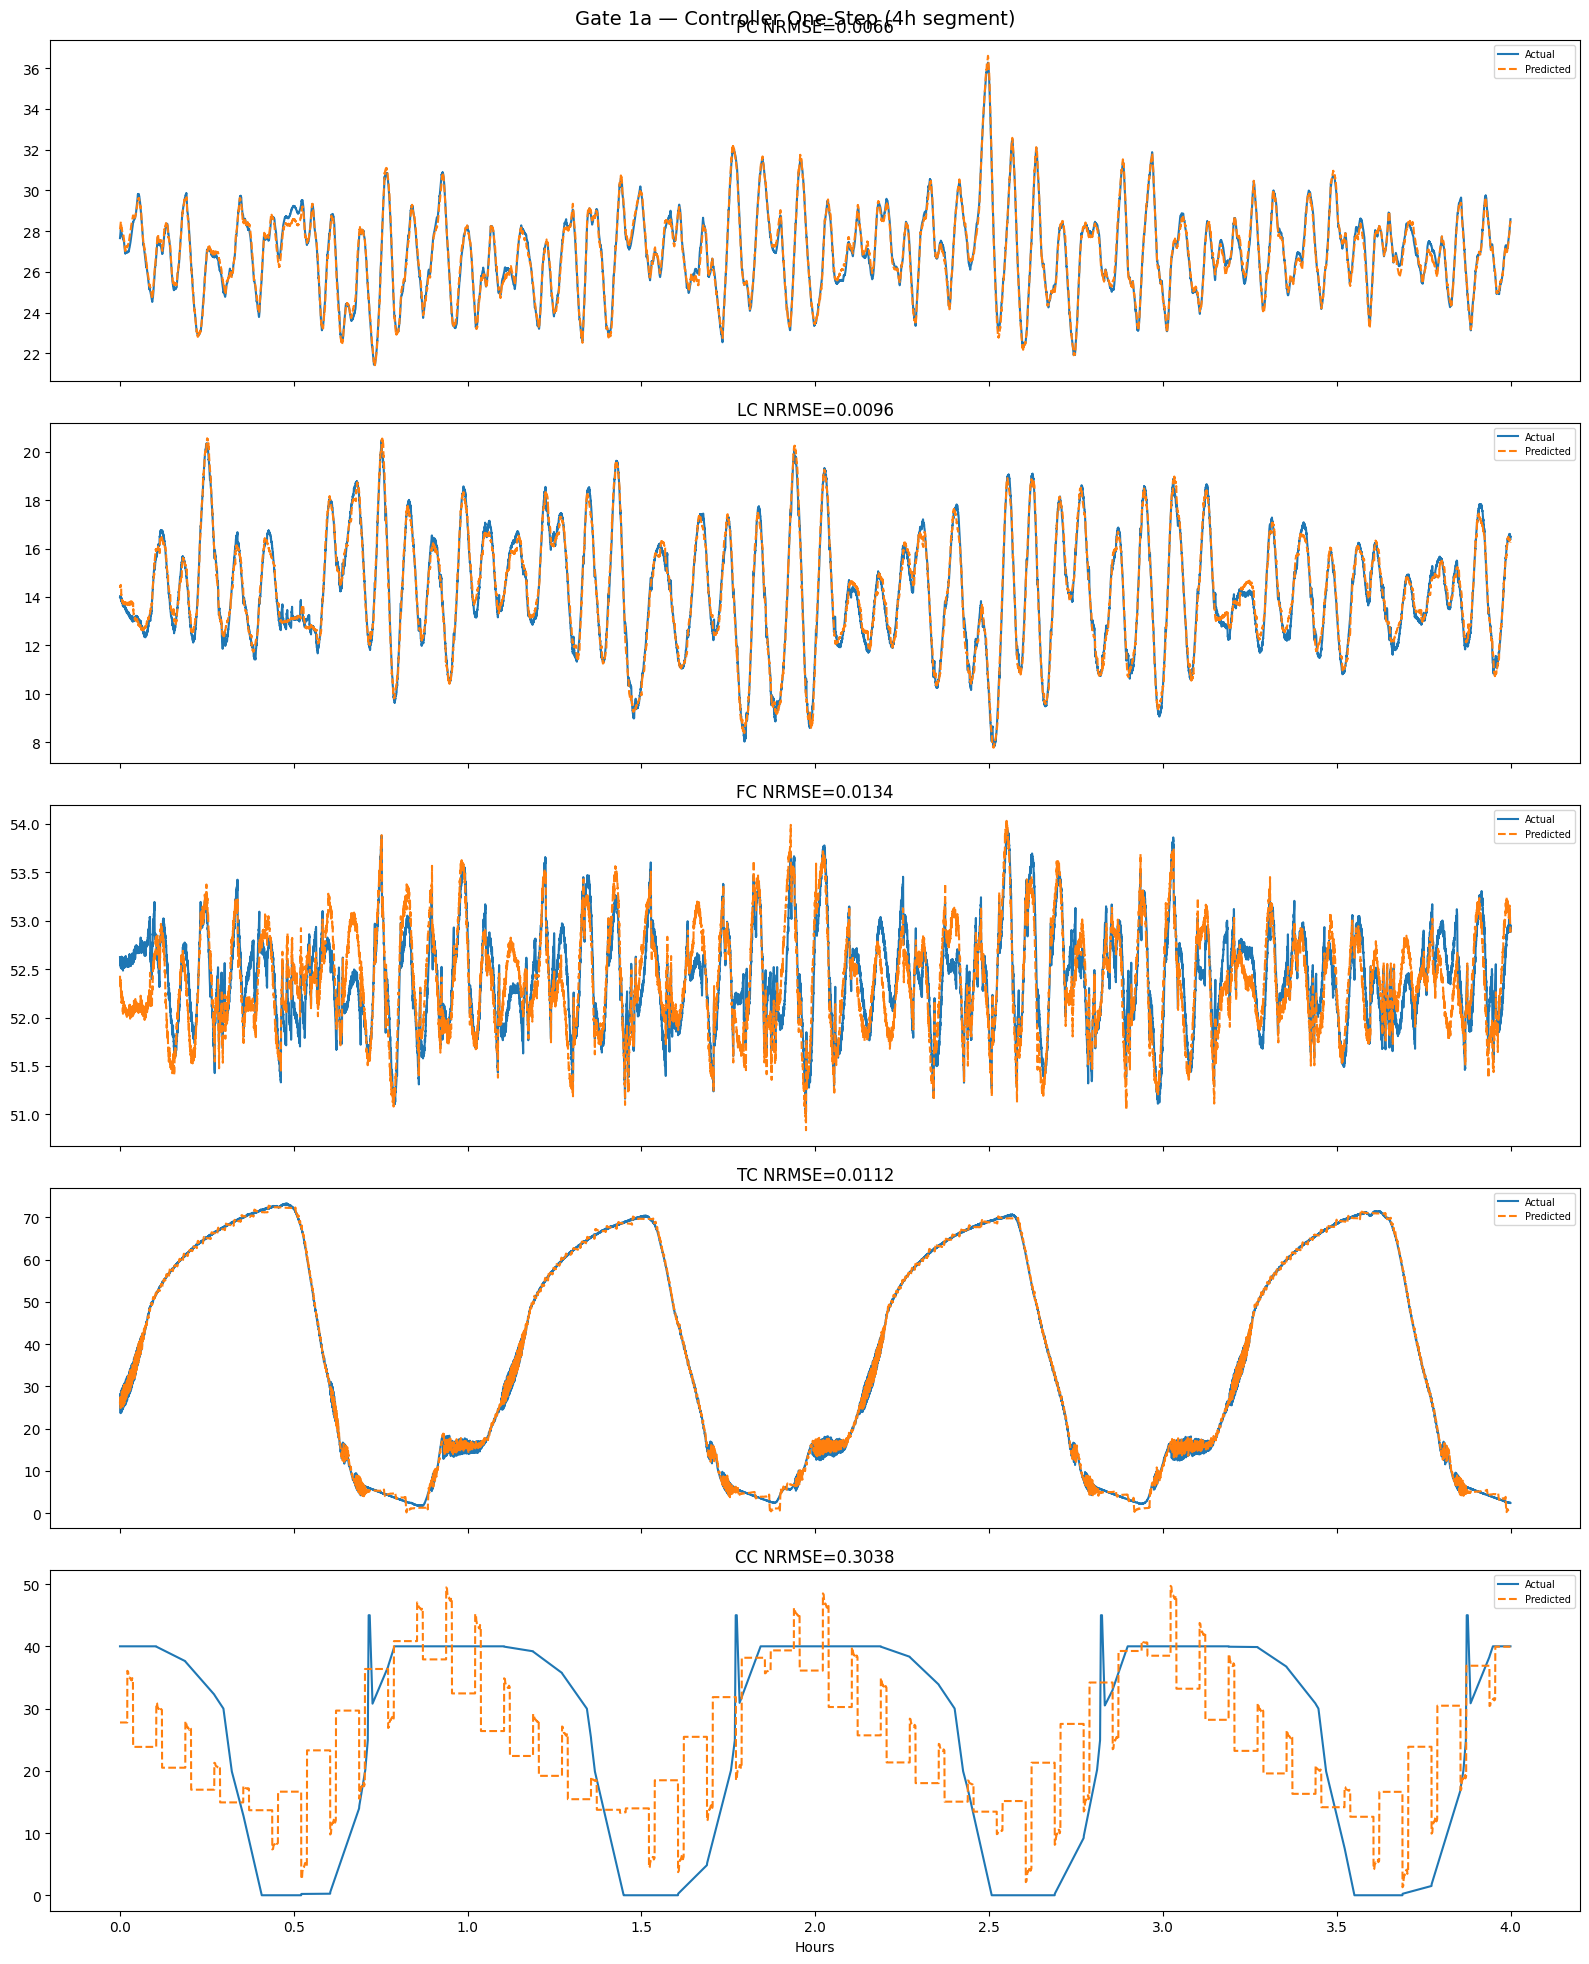


✗ FAILED: ['CC']


In [33]:
def compute_nrmse(y_true, y_pred, sig_range=None):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    if sig_range is None: sig_range = y_true.max() - y_true.min()
    return rmse / sig_range if sig_range > 1e-10 else 0.0

controller_models, controller_scalers, gate_1a_results = {}, {}, {}
print("GATE 1a — CONTROLLER MODELS")
for ln in LOOPS:
    d = controller_data[ln]
    sc = StandardScaler(); Xfs = sc.fit_transform(d['X_fit']); Xvs = sc.transform(d['X_val'])
    m = Ridge(alpha=CONFIG.ridge_alpha); m.fit(Xfs, d['y_fit'])
    yp = m.predict(Xvs)
    nrmse = compute_nrmse(d['y_val'], yp)
    passed = nrmse < CONFIG.controller_nrmse_threshold
    gate_1a_results[ln] = {'nrmse': nrmse, 'passed': passed}
    controller_models[ln] = m; controller_scalers[ln] = sc
    print(f"  {'✓' if passed else '✗'} {ln}: NRMSE={nrmse:.4f}")

fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=True)
fig.suptitle('Gate 1a — Controller One-Step (4h segment)', fontsize=14)
sl = slice(5000, 19400)
for idx, ln in enumerate(LOOPS):
    d = controller_data[ln]; yp = controller_models[ln].predict(controller_scalers[ln].transform(d['X_val']))
    t = np.arange(14400)/3600
    axes[idx].plot(t, d['y_val'][sl], label='Actual')
    axes[idx].plot(t, yp[sl], label='Predicted', linestyle='--')
    r = gate_1a_results[ln]; axes[idx].set_title(f"{ln} NRMSE={r['nrmse']:.4f}"); axes[idx].legend(fontsize=7)
axes[-1].set_xlabel('Hours'); plt.tight_layout(); plt.show()

gate_1a_failed = [k for k,r in gate_1a_results.items() if not r['passed']]
print(f"\n{'✓ GATE 1a PASSED' if not gate_1a_failed else '✗ FAILED: '+str(gate_1a_failed)}")

## Cell 7 — Linear NARX Plant (Gate 1b)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.99847e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  alpha=   100: one-step NRMSE=0.0054, max|pred|=1071.0
  → Using alpha=100
GATE 1b — PLANT ROLLOUT (10×15min)
  ✓ P1_PIT01: 0.0049±0.0009
  ✓ P1_LIT01: 0.0240±0.0025
  ✓ P1_FT03Z: 0.0063±0.0001
  ✗ P1_TIT01: 0.0892±0.0014
  ✓ P1_TIT03: 0.0234±0.0022


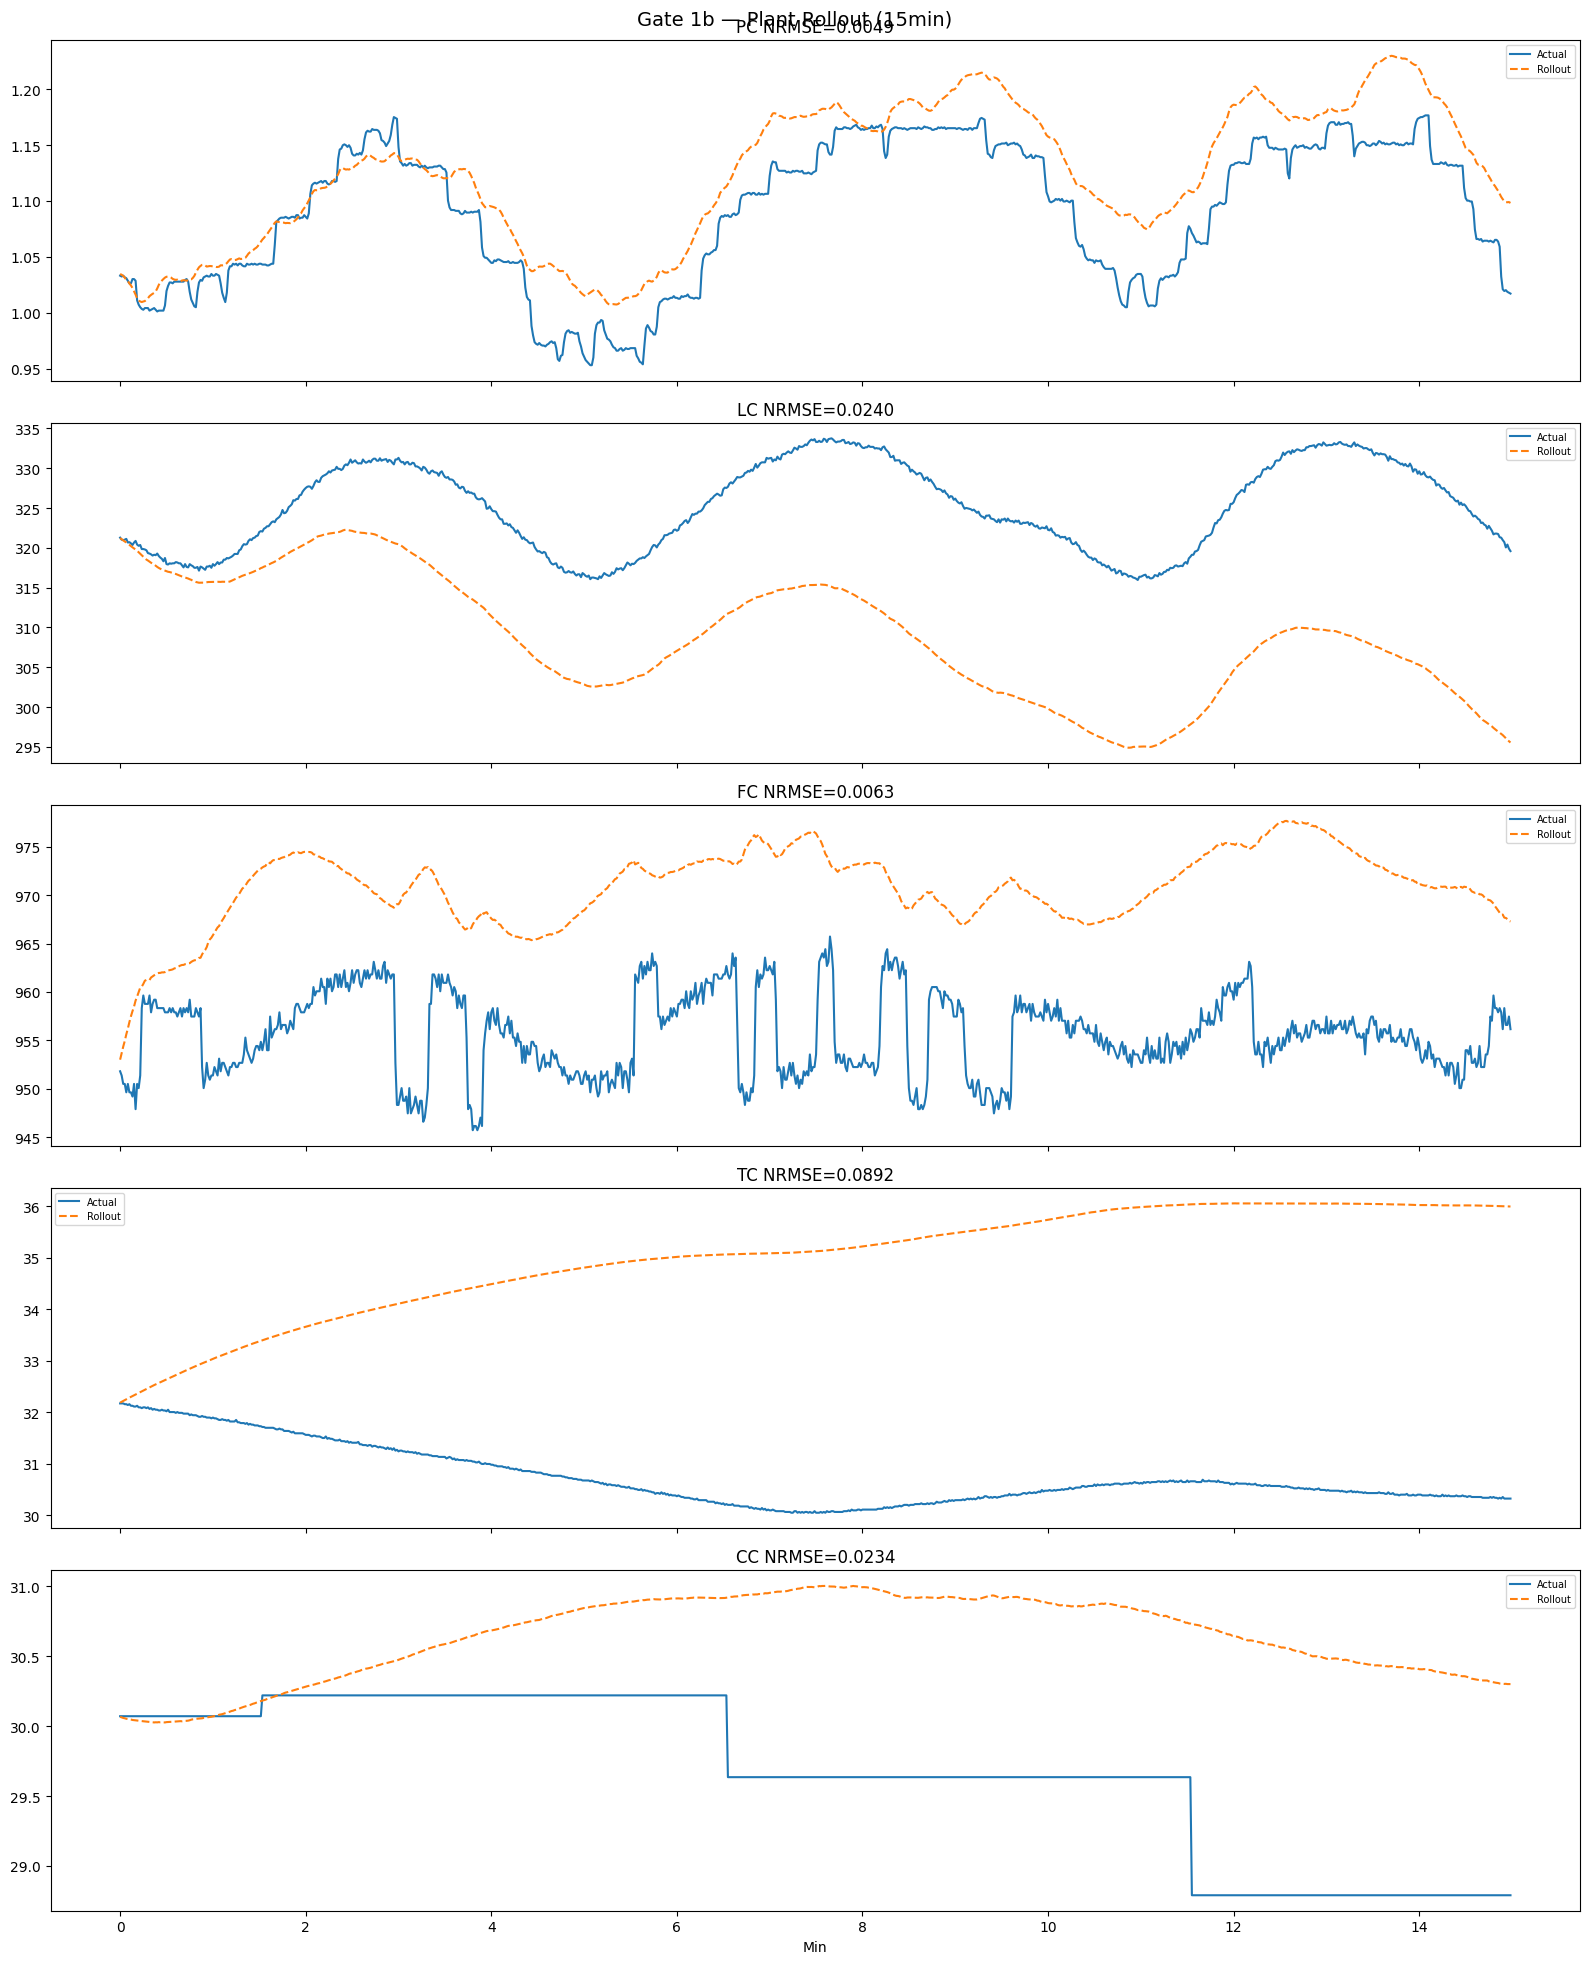


✗ GATE 1b FAILED


In [34]:
plant_scaler = StandardScaler()
Xpfs = plant_scaler.fit_transform(X_pf); Xpvs = plant_scaler.transform(X_pv)
for alpha in [100, 1000, 10000]:
    model = Ridge(alpha=alpha)
    model.fit(Xpfs, y_pf)
    yp = model.predict(Xpvs)
    max_pred = np.max(np.abs(yp))
    nrmse_avg = np.mean([compute_nrmse(y_pv[:,i], yp[:,i]) for i in range(y_pv.shape[1])])
    print(f"  alpha={alpha:>6}: one-step NRMSE={nrmse_avg:.4f}, max|pred|={max_pred:.1f}")
    if max_pred < 1e6:
        plant_model_linear = model
        print(f"  → Using alpha={alpha}")
        break

def plant_rollout(model, scaler, df_v, cv_c, pv_c, pi_cols, win, hor, start=0):
    cad = df_v[pi_cols].values; pvd = df_v[pv_c].values
    pvh = pvd[start:start+win+1].copy(); preds, acts = [], []
    for t in range(hor):
        at = start + win + t
        if at+1 >= len(cad): break
        caw = cad[at-win+1:at+1]; x = np.concatenate([caw.flatten(), pvh[-1]]).reshape(1,-1).astype(np.float32)
        pn = model.predict(scaler.transform(x))[0]
        preds.append(pn); acts.append(pvd[at+1])
        pvh = np.vstack([pvh[1:], pn.reshape(1,-1)])
    return np.array(preds), np.array(acts)

H = CONFIG.rollout_horizon
nw = min(10, (len(df_val)-W_p-H)//H)
starts = [W_p + i*H for i in range(nw)]
ro_nrmse = {c: [] for c in PV_COLS}
print(f"GATE 1b — PLANT ROLLOUT ({nw}×{H/60:.0f}min)")
for s in starts:
    pr, ac = plant_rollout(plant_model_linear, plant_scaler, df_val, CV_COLS, PV_COLS, plant_input_cols, W_p, H, s)
    for i, pc in enumerate(PV_COLS):
        ln = [k for k,l in LOOPS.items() if l.pv==pc][0]; r = LOOPS[ln].pv_range
        ro_nrmse[pc].append(compute_nrmse(ac[:,i], pr[:,i], r[1]-r[0]))

gate_1b_results = {}
for pc in PV_COLS:
    ln = [k for k,l in LOOPS.items() if l.pv==pc][0]
    v = ro_nrmse[pc]; m,s,mx = np.mean(v),np.std(v),np.max(v)
    p = m < CONFIG.plant_nrmse_threshold_rollout
    gate_1b_results[pc] = {'mean_nrmse':m,'std':s,'max':mx,'passed':p}
    print(f"  {'✓' if p else '✗'} {pc}: {m:.4f}±{s:.4f}")

pr0, ac0 = plant_rollout(plant_model_linear, plant_scaler, df_val, CV_COLS, PV_COLS, plant_input_cols, W_p, H, starts[0])
fig, axes = plt.subplots(5,1,figsize=(16,20),sharex=True)
fig.suptitle(f'Gate 1b — Plant Rollout ({H/60:.0f}min)', fontsize=14)
t = np.arange(len(pr0))/60
for i, pc in enumerate(PV_COLS):
    ln = [k for k,l in LOOPS.items() if l.pv==pc][0]; r = gate_1b_results[pc]
    axes[i].plot(t,ac0[:,i],label='Actual'); axes[i].plot(t,pr0[:,i],label='Rollout',linestyle='--')
    axes[i].set_title(f"{ln} NRMSE={r['mean_nrmse']:.4f}"); axes[i].legend(fontsize=7)
axes[-1].set_xlabel('Min'); plt.tight_layout(); plt.show()

gate_1b_passed = all(r['passed'] for r in gate_1b_results.values())
print(f"\n{'✓ GATE 1b PASSED' if gate_1b_passed else '✗ GATE 1b FAILED'}")

## Cell 8 — MLP Upgrade (Gate 2, conditional)

In [35]:
class MLPNARX(nn.Module):
    def __init__(self, ind, outd, hid=[128,64]):
        super().__init__()
        layers = []
        prev = ind
        for h in hid: layers.extend([nn.Linear(prev,h), nn.ReLU(), nn.Dropout(0.1)]); prev = h
        layers.append(nn.Linear(prev, outd))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def train_mlp(Xt, yt, Xv, yv, ind, outd, cfg, tag=""):
    if not TORCH_AVAILABLE: raise RuntimeError("No PyTorch")
    m = MLPNARX(ind, outd, cfg.mlp_hidden_dims).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=cfg.mlp_lr); crit = nn.MSELoss()
    tds = TensorDataset(torch.tensor(Xt,dtype=torch.float32), torch.tensor(yt,dtype=torch.float32))
    vds = TensorDataset(torch.tensor(Xv,dtype=torch.float32), torch.tensor(yv,dtype=torch.float32))
    tdl = DataLoader(tds, batch_size=cfg.mlp_batch_size, shuffle=True)
    vdl = DataLoader(vds, batch_size=cfg.mlp_batch_size*2)
    bvl, pc, bs = float('inf'), 0, None
    for ep in range(cfg.mlp_max_epochs):
        m.train()
        for xb,yb in tdl:
            xb,yb = xb.to(DEVICE),yb.to(DEVICE)
            loss = crit(m(xb), yb if yb.dim()>1 else yb.unsqueeze(1))
            opt.zero_grad(); loss.backward(); opt.step()
        m.eval(); vl = 0
        with torch.no_grad():
            for xb,yb in vdl:
                xb,yb = xb.to(DEVICE),yb.to(DEVICE)
                vl += crit(m(xb), yb if yb.dim()>1 else yb.unsqueeze(1)).item()*len(xb)
        vl /= len(vds)
        if vl < bvl: bvl=vl; pc=0; bs={k:v.cpu().clone() for k,v in m.state_dict().items()}
        else: pc += 1
        if ep%10==0: print(f"  [{tag}] ep{ep}: val={vl:.6f} pat={pc}")
        if pc >= cfg.mlp_patience: print(f"  [{tag}] early stop ep{ep}"); break
    m.load_state_dict(bs); m.eval(); return m

def mlp_predict(m, X, bs=4096):
    m.eval(); ps = []
    with torch.no_grad():
        for i in range(0,len(X),bs):
            ps.append(m(torch.tensor(X[i:i+bs],dtype=torch.float32).to(DEVICE)).cpu().numpy())
    return np.vstack(ps)

needs_upgrade = bool(gate_1a_failed) or not gate_1b_passed
ctrl_types = {k:'linear' for k in LOOPS}

if not needs_upgrade:
    print("✓ Both gates passed. Skipping MLP.")
    plant_model, plant_type = plant_model_linear, 'linear'
elif not TORCH_AVAILABLE:
    print("⚠ No PyTorch. Cannot upgrade.")
    plant_model, plant_type = plant_model_linear, 'linear'
else:
    for ln in gate_1a_failed:
        print(f"\nUpgrading {ln} controller...")
        d = controller_data[ln]; Xs = controller_scalers[ln].transform(d['X_fit']); Xv = controller_scalers[ln].transform(d['X_val'])
        mlp = train_mlp(Xs, d['y_fit'].reshape(-1,1), Xv, d['y_val'].reshape(-1,1), Xs.shape[1], 1, CONFIG, ln)
        controller_models[ln] = mlp; ctrl_types[ln] = 'mlp'
        print(f"  NRMSE={compute_nrmse(d['y_val'], mlp_predict(mlp,Xv).flatten()):.4f}")
    if not gate_1b_passed:
        print("\nUpgrading plant...")
        plant_model = train_mlp(Xpfs, y_pf, Xpvs, y_pv, Xpfs.shape[1], y_pf.shape[1], CONFIG, 'plant')
        plant_type = 'mlp'
    else:
        plant_model, plant_type = plant_model_linear, 'linear'

if not needs_upgrade:
    plant_model, plant_type = plant_model_linear, 'linear'

print(f"\nFinal: ctrl={ctrl_types}, plant={plant_type}")


Upgrading CC controller...
  [CC] ep0: val=177.398146 pat=0
  [CC] ep10: val=167.307385 pat=3
  [CC] ep20: val=166.487298 pat=7
  [CC] early stop ep23
  NRMSE=0.2854

Upgrading plant...
  [plant] ep0: val=444.307690 pat=0
  [plant] ep10: val=56.578843 pat=0
  [plant] ep20: val=69.118706 pat=10
  [plant] early stop ep20

Final: ctrl={'PC': 'linear', 'LC': 'linear', 'FC': 'linear', 'TC': 'linear', 'CC': 'mlp'}, plant=mlp


## Cell 9 — Closed-Loop Validation (Gate 3)

GATE 3 — CLOSED LOOP
  Window 1: 3.7s
  Window 2: 3.5s
  Window 3: 3.6s
  Window 4: 3.5s
  Window 5: 3.6s
  Window 6: 3.6s
  Window 7: 3.6s
  Window 8: 3.6s
  ✗ P1_PIT01: 0.1516±0.0480
  ✗ P1_LIT01: 0.3264±0.0623
  ✗ P1_FT03Z: 0.3173±0.0898
  ✗ P1_TIT01: 0.2340±0.0495
  ✗ P1_TIT03: 0.2527±0.0545


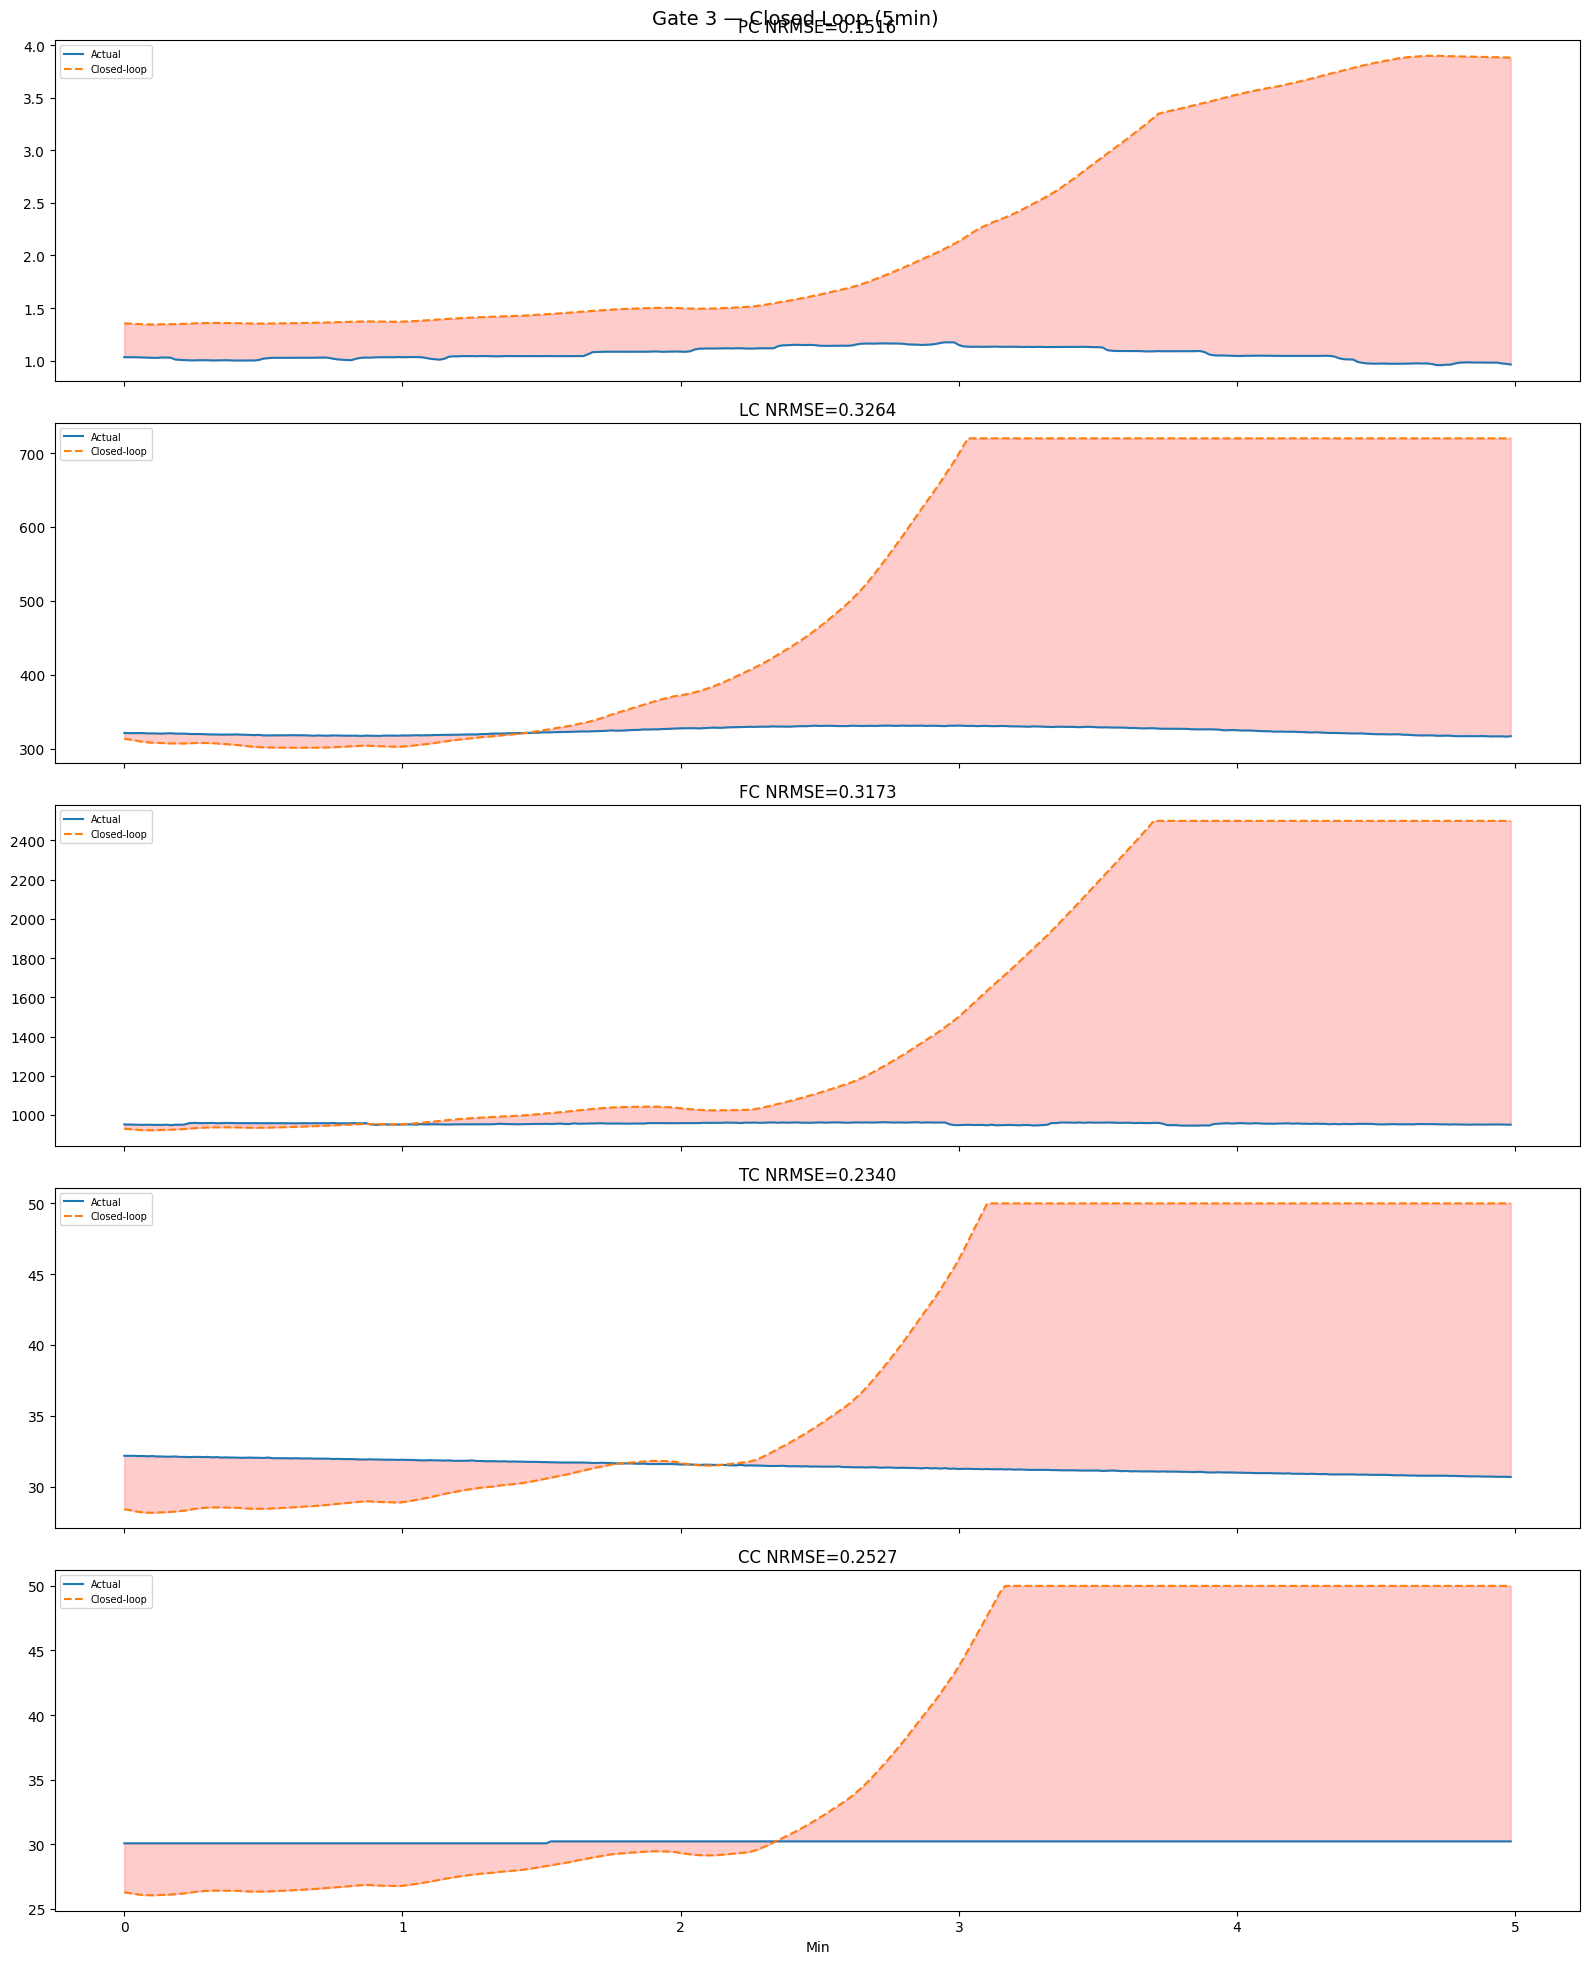


✗ GATE 3 FAILED — try shorter rollout or training noise


In [46]:
CONFIG.rollout_horizon = 300  # 5 min instead of 15
# Physical limits for clamping
CV_LIMITS = {
    'PC': (0, 100), 'LC': (0, 100), 'FC': (0, 100),
    'TC': (0, 100), 'CC': (0, 50),
}
PV_LIMITS = {
    'P1_PIT01': (0, 10), 'P1_LIT01': (0, 720), 'P1_FT03Z': (0, 2500),
    'P1_TIT01': (0, 50), 'P1_TIT03': (0, 50),
}

def ctrl_step(ln, hist, _):
    m, sc = controller_models[ln], controller_scalers[ln]
    x = sc.transform(hist[ln].flatten().reshape(1,-1).astype(np.float32))
    raw = mlp_predict(m,x).flatten()[0] if ctrl_types.get(ln)=='mlp' else m.predict(x).flatten()[0]
    lo, hi = CV_LIMITS[ln]
    return np.clip(raw, lo, hi)

def plant_step(cv_hist, cur_pv):
    x = np.concatenate([cv_hist.flatten(), cur_pv]).reshape(1,-1).astype(np.float32)
    xs = plant_scaler.transform(x)
    raw = mlp_predict(plant_model,xs).flatten() if plant_type=='mlp' else plant_model.predict(xs).flatten()
    for i, col in enumerate(PV_COLS):
        lo, hi = PV_LIMITS[col]
        raw[i] = np.clip(raw[i], lo, hi)
    return raw

def closed_loop_rollout(df, si, hor, wc, wp):
    lns = list(LOOPS.keys()); mw = max(wc, wp)
    ch = {}
    for ln, lp in LOOPS.items():
        ic = [lp.sp, lp.pv] + ([lp.cv_fb] if lp.cv_fb else [])
        ch[ln] = df[ic].iloc[si:si+wc].values.copy()
    pch = df[plant_input_cols].iloc[si:si+wp].values.copy()
    cpv = df[PV_COLS].iloc[si+wp].values.copy()
    ppv,pcv,apv,acv = [],[],[],[]
    for t in range(hor):
        at = si + mw + t
        if at+1 >= len(df): break
        cvs = {ln: ctrl_step(ln, ch, wc) for ln in lns}
        car = df[plant_input_cols].iloc[at].values.copy()
        for ln in lns:
            cc = LOOPS[ln].cv
            if cc in plant_input_cols: car[plant_input_cols.index(cc)] = cvs[ln]
        pch = np.vstack([pch[1:], car.reshape(1,-1)])
        npv = plant_step(pch, cpv)
        ppv.append(npv.copy()); pcv.append(np.array([cvs[ln] for ln in lns]))
        apv.append(df[PV_COLS].iloc[at+1].values); acv.append(df[CV_COLS].iloc[at+1].values)
        cpv = npv.copy()
        for ln, lp in LOOPS.items():
            ic = [lp.sp, lp.pv] + ([lp.cv_fb] if lp.cv_fb else [])
            nr = []
            for c in ic:
                if c==lp.pv: nr.append(cpv[PV_COLS.index(lp.pv)])
                elif c==lp.sp: nr.append(df[c].iloc[at+1])
                elif c==lp.cv_fb: nr.append(cvs[ln])
                else: nr.append(df[c].iloc[at+1])
            ch[ln] = np.vstack([ch[ln][1:], np.array(nr).reshape(1,-1)])
    return np.array(ppv), np.array(pcv), np.array(apv), np.array(acv)

print("GATE 3 — CLOSED LOOP")
H = CONFIG.rollout_horizon; mw = max(CONFIG.W_controller, CONFIG.W_plant)
nw = min(8, (len(df_val)-mw-H)//H)
cln = {c:[] for c in PV_COLS}
for wi in range(nw):
    t0 = time.time()
    pp,pc,ap,ac = closed_loop_rollout(df_val, mw+wi*H, H, CONFIG.W_controller, CONFIG.W_plant)
    for i,c in enumerate(PV_COLS):
        ln=[k for k,l in LOOPS.items() if l.pv==c][0]; r=LOOPS[ln].pv_range
        cln[c].append(compute_nrmse(ap[:,i],pp[:,i],r[1]-r[0]))
    if wi==0: clp,cla = pp,ap
    print(f"  Window {wi+1}: {time.time()-t0:.1f}s")

g3r = {}
for c in PV_COLS:
    ln=[k for k,l in LOOPS.items() if l.pv==c][0]; v=cln[c]
    m,s,mx = np.mean(v),np.std(v),np.max(v); p = m<CONFIG.closedloop_nrmse_threshold
    g3r[c] = {'mean_nrmse':m,'std':s,'max':mx,'passed':p}
    print(f"  {'✓' if p else '✗'} {c}: {m:.4f}±{s:.4f}")

fig, axes = plt.subplots(5,1,figsize=(16,20),sharex=True)
fig.suptitle(f'Gate 3 — Closed Loop ({H/60:.0f}min)', fontsize=14)
t = np.arange(len(clp))/60
for i,c in enumerate(PV_COLS):
    ln=[k for k,l in LOOPS.items() if l.pv==c][0]; r=g3r[c]
    axes[i].plot(t,cla[:,i],label='Actual'); axes[i].plot(t,clp[:,i],label='Closed-loop',linestyle='--')
    axes[i].fill_between(t,cla[:,i],clp[:,i],alpha=0.2,color='red')
    axes[i].set_title(f"{ln} NRMSE={r['mean_nrmse']:.4f}"); axes[i].legend(fontsize=7)
axes[-1].set_xlabel('Min'); plt.tight_layout(); plt.show()

g3p = all(r['passed'] for r in g3r.values())
print(f"\n{'✓ GATE 3 PASSED' if g3p else '✗ GATE 3 FAILED — try shorter rollout or training noise'}")
gate_3_results, gate_3_passed = g3r, g3p

## Cell 10 — Validation (Levels 1 & 2)

LEVEL 1 & 2 VALIDATION


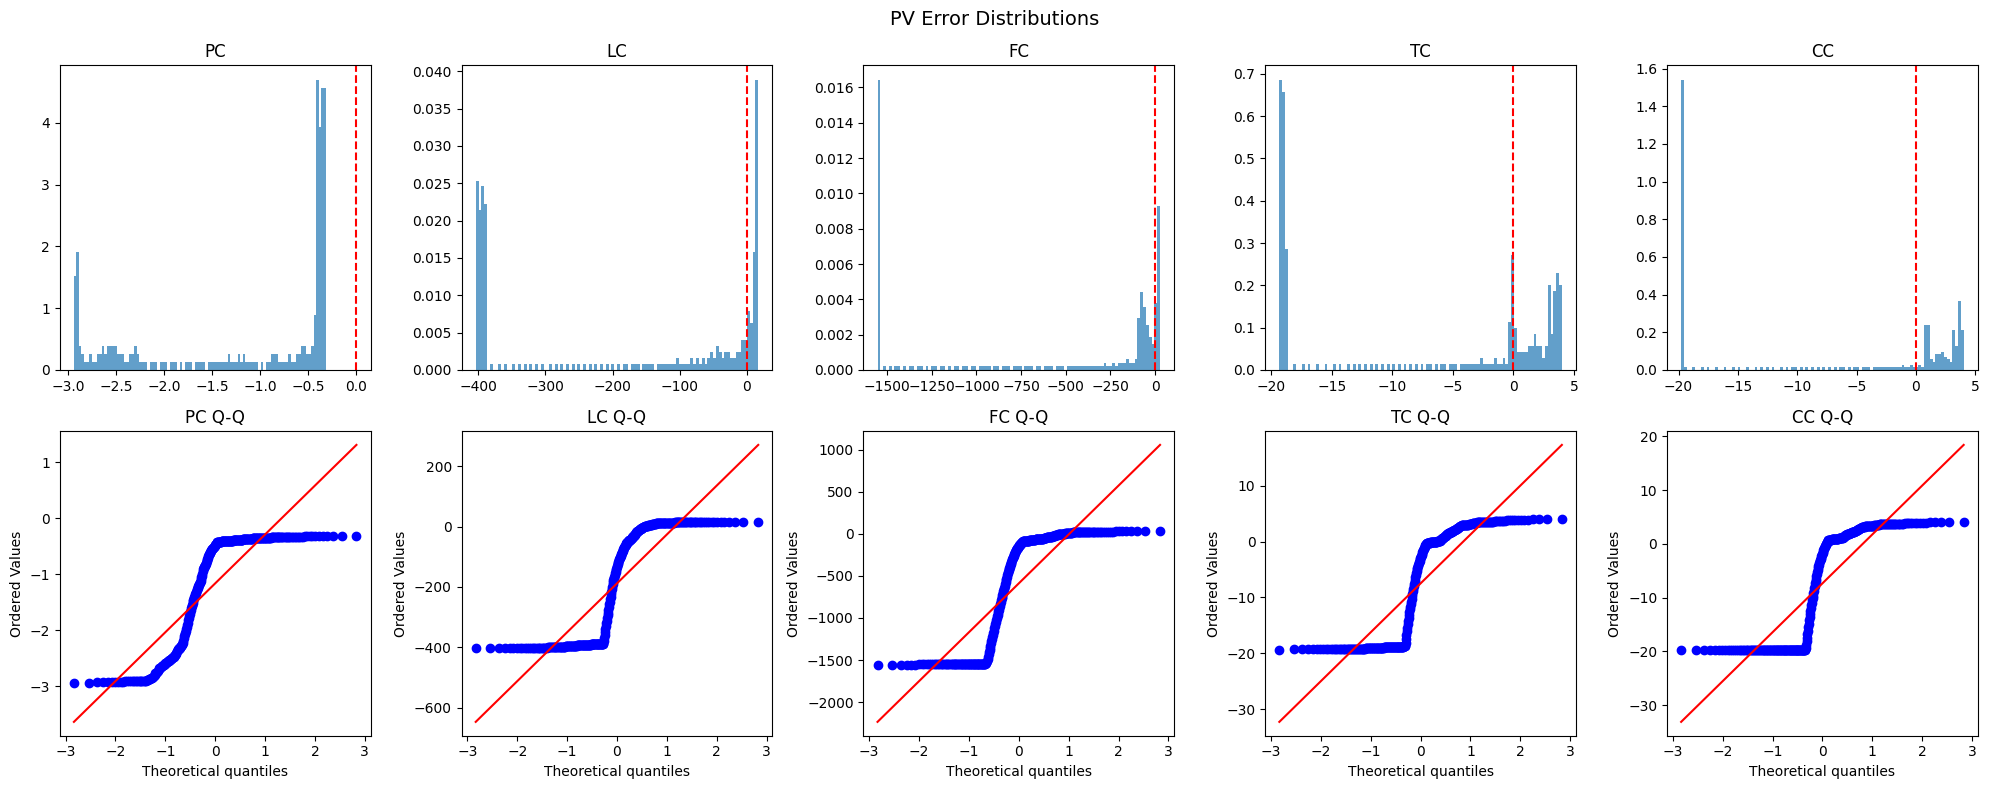


KS test on tracking error:
  PC: KS=1.0000 ⚠
  LC: KS=0.6767 ⚠
  FC: KS=0.7800 ⚠
  TC: KS=0.5367 ⚠
  CC: KS=0.5300 ⚠


In [37]:
print("LEVEL 1 & 2 VALIDATION")
fig, axes = plt.subplots(2,5,figsize=(20,8))
fig.suptitle('PV Error Distributions', fontsize=14)
for i,c in enumerate(PV_COLS):
    ln=[k for k,l in LOOPS.items() if l.pv==c][0]; err = cla[:,i]-clp[:,i]
    axes[0,i].hist(err,bins=100,density=True,alpha=0.7); axes[0,i].set_title(f'{ln}'); axes[0,i].axvline(0,color='r',linestyle='--')
    probplot(err,dist="norm",plot=axes[1,i]); axes[1,i].set_title(f'{ln} Q-Q')
plt.tight_layout(); plt.show()

print("\nKS test on tracking error:")
for ln, lp in LOOPS.items():
    pi = PV_COLS.index(lp.pv); sp = df_val[lp.sp].iloc[mw:mw+len(cla)].values[:len(cla)]
    re = sp - cla[:,pi]; se = sp - clp[:,pi]
    ks,p = ks_2samp(re[:5000],se[:5000])
    print(f"  {ln}: KS={ks:.4f} {'✓' if ks<0.1 else '⚠'}")

## Cell 11 — HMM Setpoint Generator

HMM:
  PC: 55629 trans (286.7/hr), SP=1.12±0.10
  LC: 680 trans (3.5/hr), SP=350.79±21.02
  FC: 622 trans (3.2/hr), SP=996.31±22.41
  TC: 176 trans (0.9/hr), SP=26.46±0.75
  CC: 67 trans (0.3/hr), SP=27.56±0.21


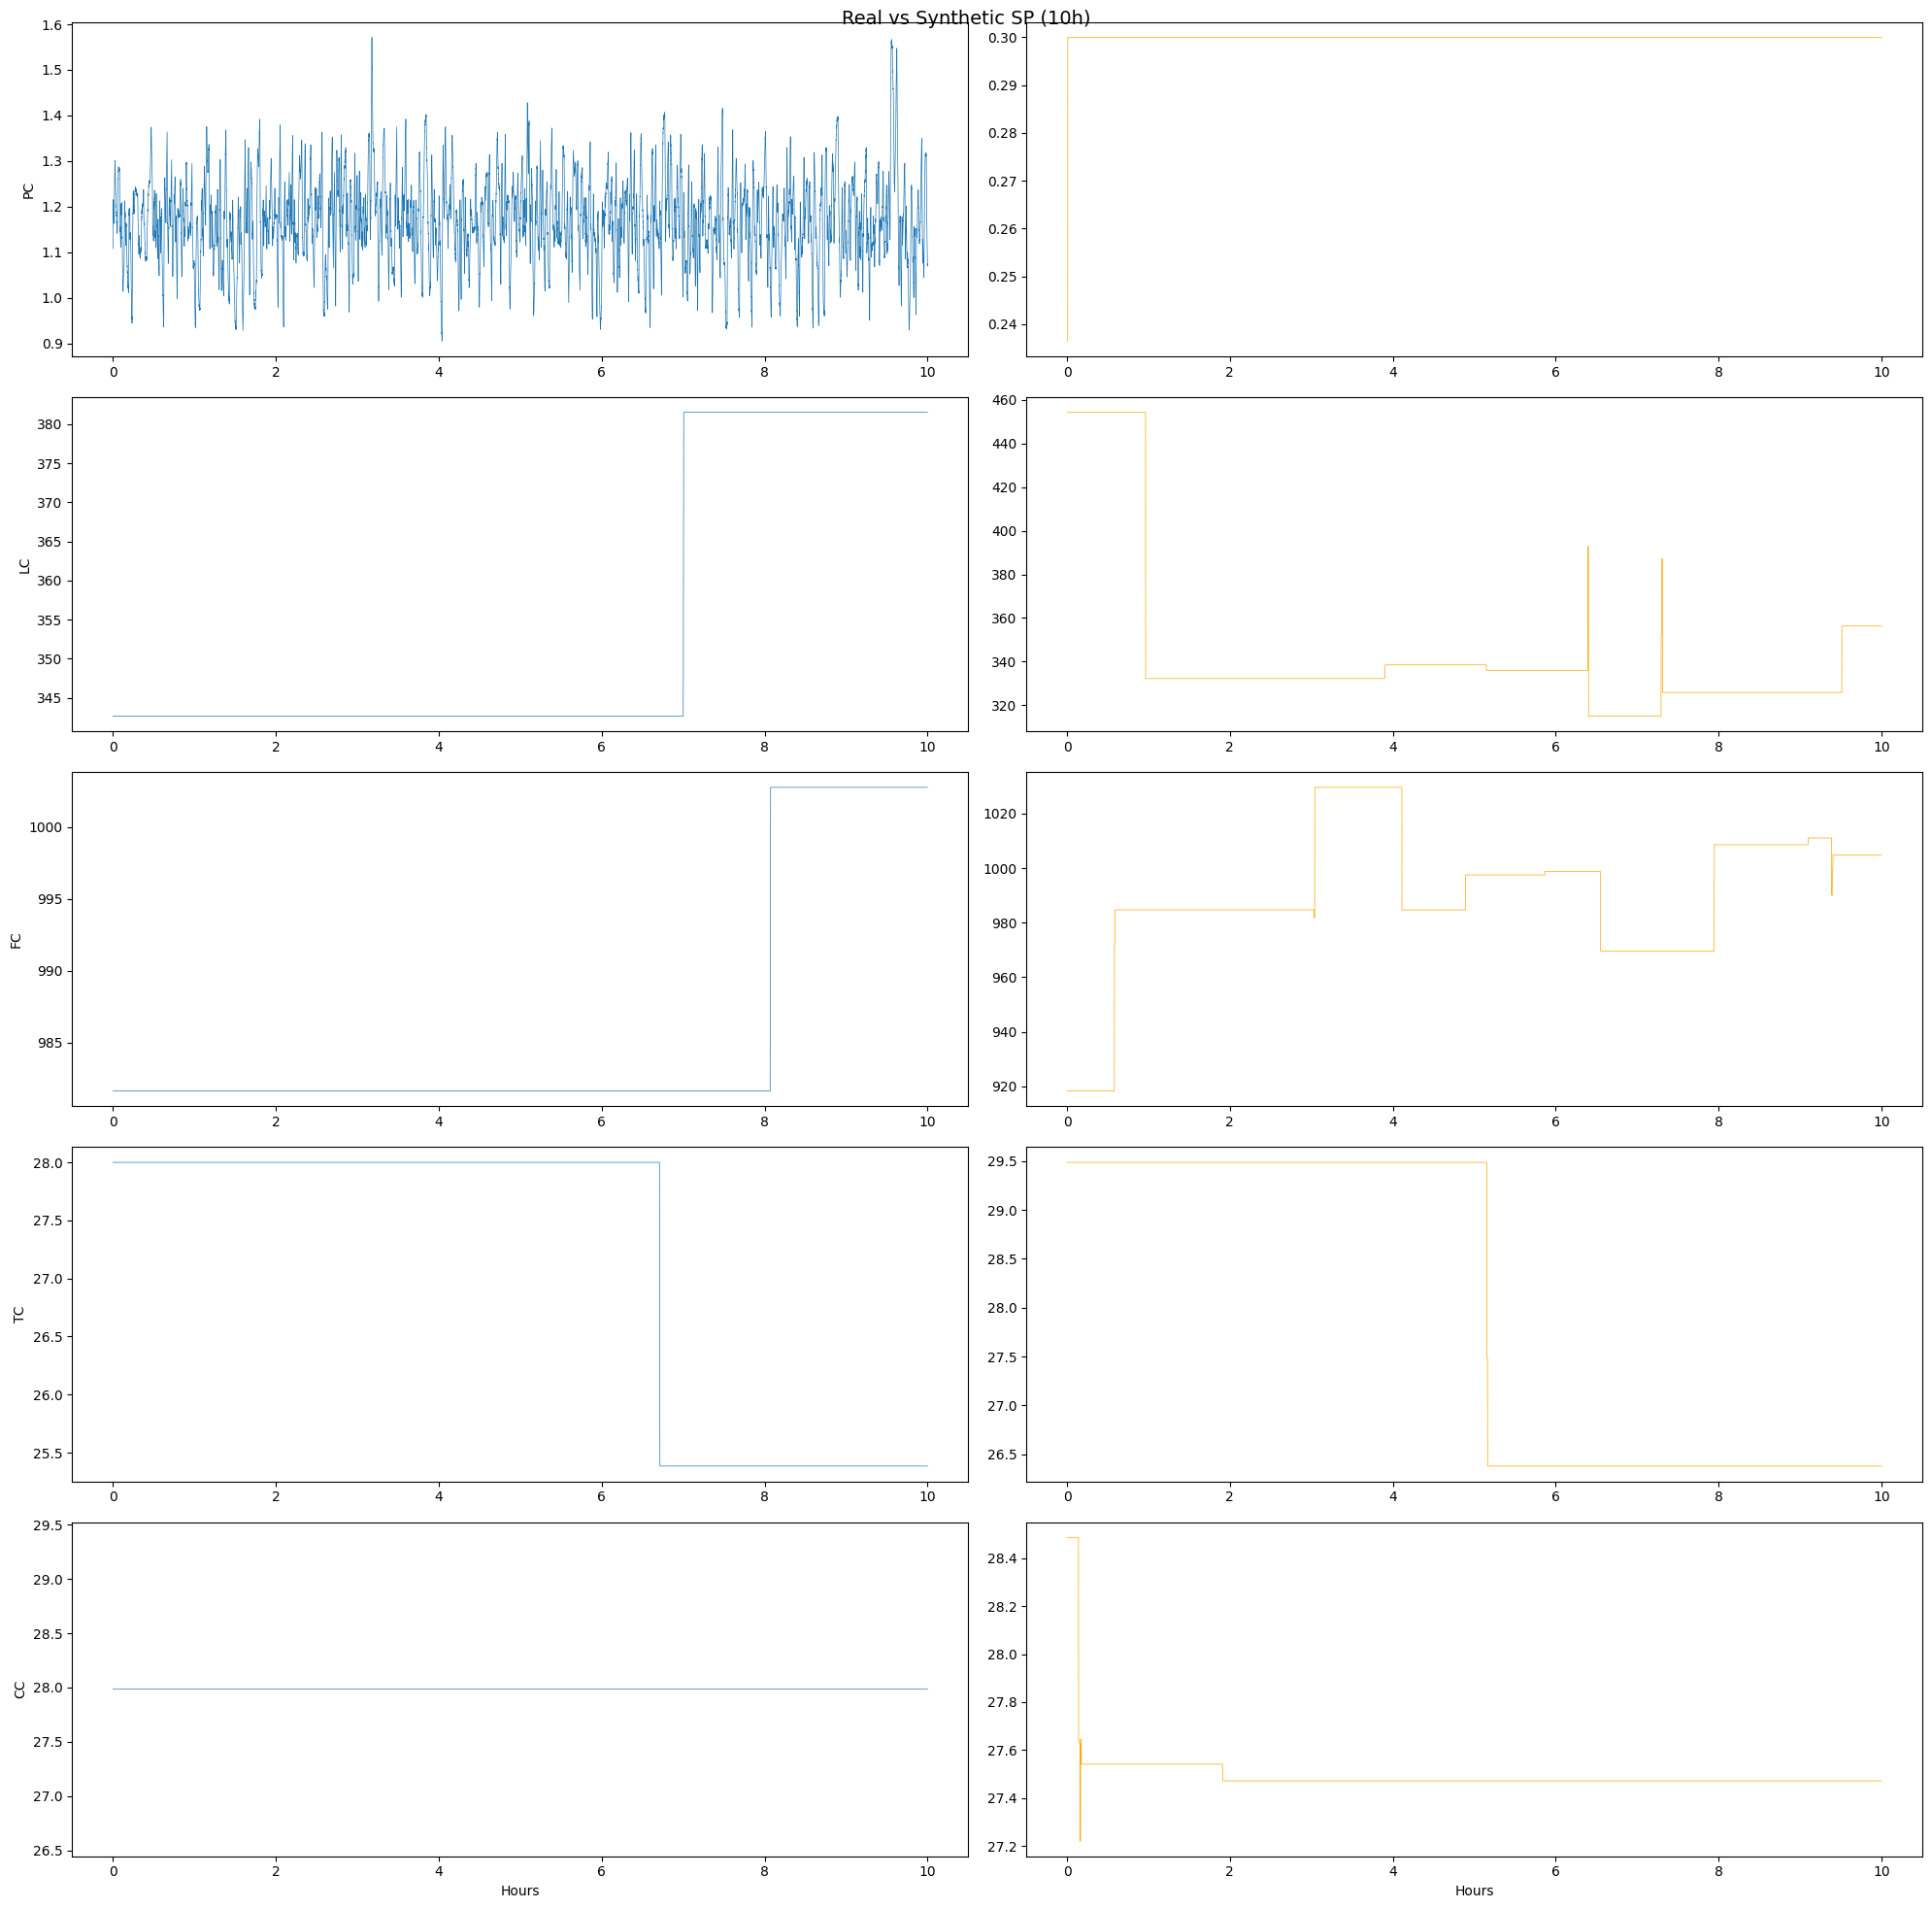

In [38]:
class SPGenerator:
    def __init__(self): self.params = {}
    def fit(self, df, loops):
        for ln, lp in loops.items():
            sp = df[lp.sp].values; r = sp.max()-sp.min()
            if r < 1e-10: self.params[ln] = {'type':'steady','val':sp[0]}; continue
            ci = np.where(np.abs(np.diff(sp)) > r*0.01)[0]
            if len(ci)<5: self.params[ln] = {'type':'steady','val':np.mean(sp)}; continue
            dw = np.diff(np.concatenate([[0],ci])); tv = sp[ci+1]
            self.params[ln] = {'type':'trans','vals':tv,'dw':dw,'dw_m':np.mean(dw),'dw_s':np.std(dw),
                'sp_min':lp.sp_range[0],'sp_max':lp.sp_range[1],'sp_m':np.mean(tv),'sp_s':np.std(tv),
                'n':len(ci),'rate':len(ci)/(len(sp)/3600)}
    def generate(self, dur, rng=None):
        if rng is None: rng = np.random.default_rng(42)
        out = {}
        for ln, p in self.params.items():
            s = np.zeros(dur)
            if p['type']=='steady': s[:]=p['val']
            else:
                t,v = 0, rng.uniform(p['sp_min'],p['sp_max'])
                while t<dur:
                    d = max(30,int(rng.normal(p['dw_m'],p['dw_s']))); s[t:min(t+d,dur)]=v
                    v = np.clip(rng.normal(p['sp_m'],p['sp_s']),p['sp_min'],p['sp_max']); t+=d
            out[ln]=s
        return out
    def summary(self):
        for ln,p in self.params.items():
            if p['type']=='steady': print(f"  {ln}: STEADY={p['val']:.3f}")
            else: print(f"  {ln}: {p['n']} trans ({p['rate']:.1f}/hr), SP={p['sp_m']:.2f}±{p['sp_s']:.2f}")

spg = SPGenerator(); spg.fit(df_fit, LOOPS)
print("HMM:"); spg.summary()

ts = spg.generate(36000, np.random.default_rng(123))
fig, axes = plt.subplots(5,2,figsize=(20,20))
fig.suptitle('Real vs Synthetic SP (10h)', fontsize=14)
for i,(ln,lp) in enumerate(LOOPS.items()):
    axes[i,0].plot(np.arange(36000)/3600, df_fit[lp.sp].iloc[:36000].values, linewidth=0.5); axes[i,0].set_ylabel(ln)
    axes[i,1].plot(np.arange(36000)/3600, ts[ln], linewidth=0.5, color='orange')
axes[-1,0].set_xlabel('Hours'); axes[-1,1].set_xlabel('Hours'); plt.tight_layout(); plt.show()

## Cell 12 — Attack Injection Framework

In [39]:
from enum import Enum

class AttackType(Enum):
    BIAS="bias"; RAMP="ramp"; FREEZE="freeze"; STEP="step"; NOISE="noise"; SCALE="scale"

@dataclass
class AttackSpec:
    target_loop: str; injection_point: str; attack_type: AttackType
    onset: int; duration: int; magnitude: float=0.0; rate: float=0.0
    noise_std: float=0.0; description: str=""
    def is_active(self, t): return self.onset <= t < self.onset + self.duration
    def apply_val(self, val, t):
        if not self.is_active(t): return val
        rt = t - self.onset
        if self.attack_type==AttackType.BIAS: return val+self.magnitude
        elif self.attack_type==AttackType.RAMP: return val+self.rate*rt
        elif self.attack_type==AttackType.STEP: return self.magnitude
        elif self.attack_type==AttackType.NOISE: return val+np.random.normal(0,self.noise_std)
        elif self.attack_type==AttackType.SCALE: return val*self.magnitude
        return val  # FREEZE handled externally

def run_attack_sim(df, si, dur, attacks, wc, wp):
    lns = list(LOOPS.keys()); mw = max(wc,wp)
    ch = {}
    for ln,lp in LOOPS.items():
        ic=[lp.sp,lp.pv]+([lp.cv_fb] if lp.cv_fb else [])
        ch[ln]=df[ic].iloc[si:si+wc].values.copy()
    pch = df[plant_input_cols].iloc[si:si+wp].values.copy()
    cpv = df[PV_COLS].iloc[si+wp].values.copy()
    spa={ln:[a for a in attacks if a.target_loop==ln and a.injection_point=='SP'] for ln in lns}
    cva={ln:[a for a in attacks if a.target_loop==ln and a.injection_point=='CV'] for ln in lns}
    pva={ln:[a for a in attacks if a.target_loop==ln and a.injection_point=='PV'] for ln in lns}
    frozen={}; recs=[]

    for t in range(dur):
        at = si+mw+t
        if at+1>=len(df): break
        rec={'time':t}; active=False
        rsp = {ln: df[LOOPS[ln].sp].iloc[at] for ln in lns}
        # SP attacks
        ssp = {}
        for ln in lns:
            v=rsp[ln]
            for a in spa[ln]:
                if a.is_active(t): v=a.apply_val(v,t); active=True
            ssp[ln]=v
        # PV spoofing
        pvs = {}
        for ln,lp in LOOPS.items():
            pr = cpv[PV_COLS.index(lp.pv)]; ps=pr
            for a in pva[ln]:
                if a.is_active(t):
                    if a.attack_type==AttackType.FREEZE:
                        if ln not in frozen: frozen[ln]=pr
                        ps=frozen[ln]
                    else: ps=a.apply_val(pr,t)
                    active=True
                elif ln in frozen: del frozen[ln]
            pvs[ln]=ps
        # Controllers
        icv = {}
        for ln,lp in LOOPS.items():
            ic=[lp.sp,lp.pv]+([lp.cv_fb] if lp.cv_fb else [])
            nr=[]
            for c in ic:
                if c==lp.pv: nr.append(pvs[ln])
                elif c==lp.sp: nr.append(ssp[ln])
                elif c==lp.cv_fb: nr.append(df[c].iloc[at])
                else: nr.append(df[c].iloc[at])
            ch[ln]=np.vstack([ch[ln][1:],np.array(nr).reshape(1,-1)])
            icv[ln]=ctrl_step(ln,ch,wc)
        # CV attacks
        acv={}
        for ln in lns:
            v=icv[ln]
            for a in cva[ln]:
                if a.is_active(t): v=a.apply_val(v,t); active=True
            acv[ln]=v
        # Plant
        car=df[plant_input_cols].iloc[at].values.copy()
        for ln in lns:
            cc=LOOPS[ln].cv
            if cc in plant_input_cols: car[plant_input_cols.index(cc)]=acv[ln]
        pch=np.vstack([pch[1:],car.reshape(1,-1)])
        npv=plant_step(pch,cpv)
        for ln in lns:
            pi=PV_COLS.index(LOOPS[ln].pv)
            rec.update({f'{ln}_SP_real':rsp[ln],f'{ln}_SP_seen':ssp[ln],
                f'{ln}_CV_intended':icv[ln],f'{ln}_CV_actual':acv[ln],
                f'{ln}_PV_real':npv[pi],f'{ln}_PV_seen':pvs[ln]})
        rec['attack_label']=1 if active else 0; recs.append(rec)
        cpv=npv.copy()
    return pd.DataFrame(recs)

print("✓ Attack framework ready: types={}, points=SP/CV/PV, loops={}".format(
    [a.value for a in AttackType], list(LOOPS.keys())))

✓ Attack framework ready: types=['bias', 'ramp', 'freeze', 'step', 'noise', 'scale'], points=SP/CV/PV, loops=['PC', 'LC', 'FC', 'TC', 'CC']


## Cell 13 — Attack Sanity Checks

ATTACK SANITY CHECKS

  SP Bias LC +20...

  CV Freeze FC...

  PV Freeze PC...

  Combined LC...


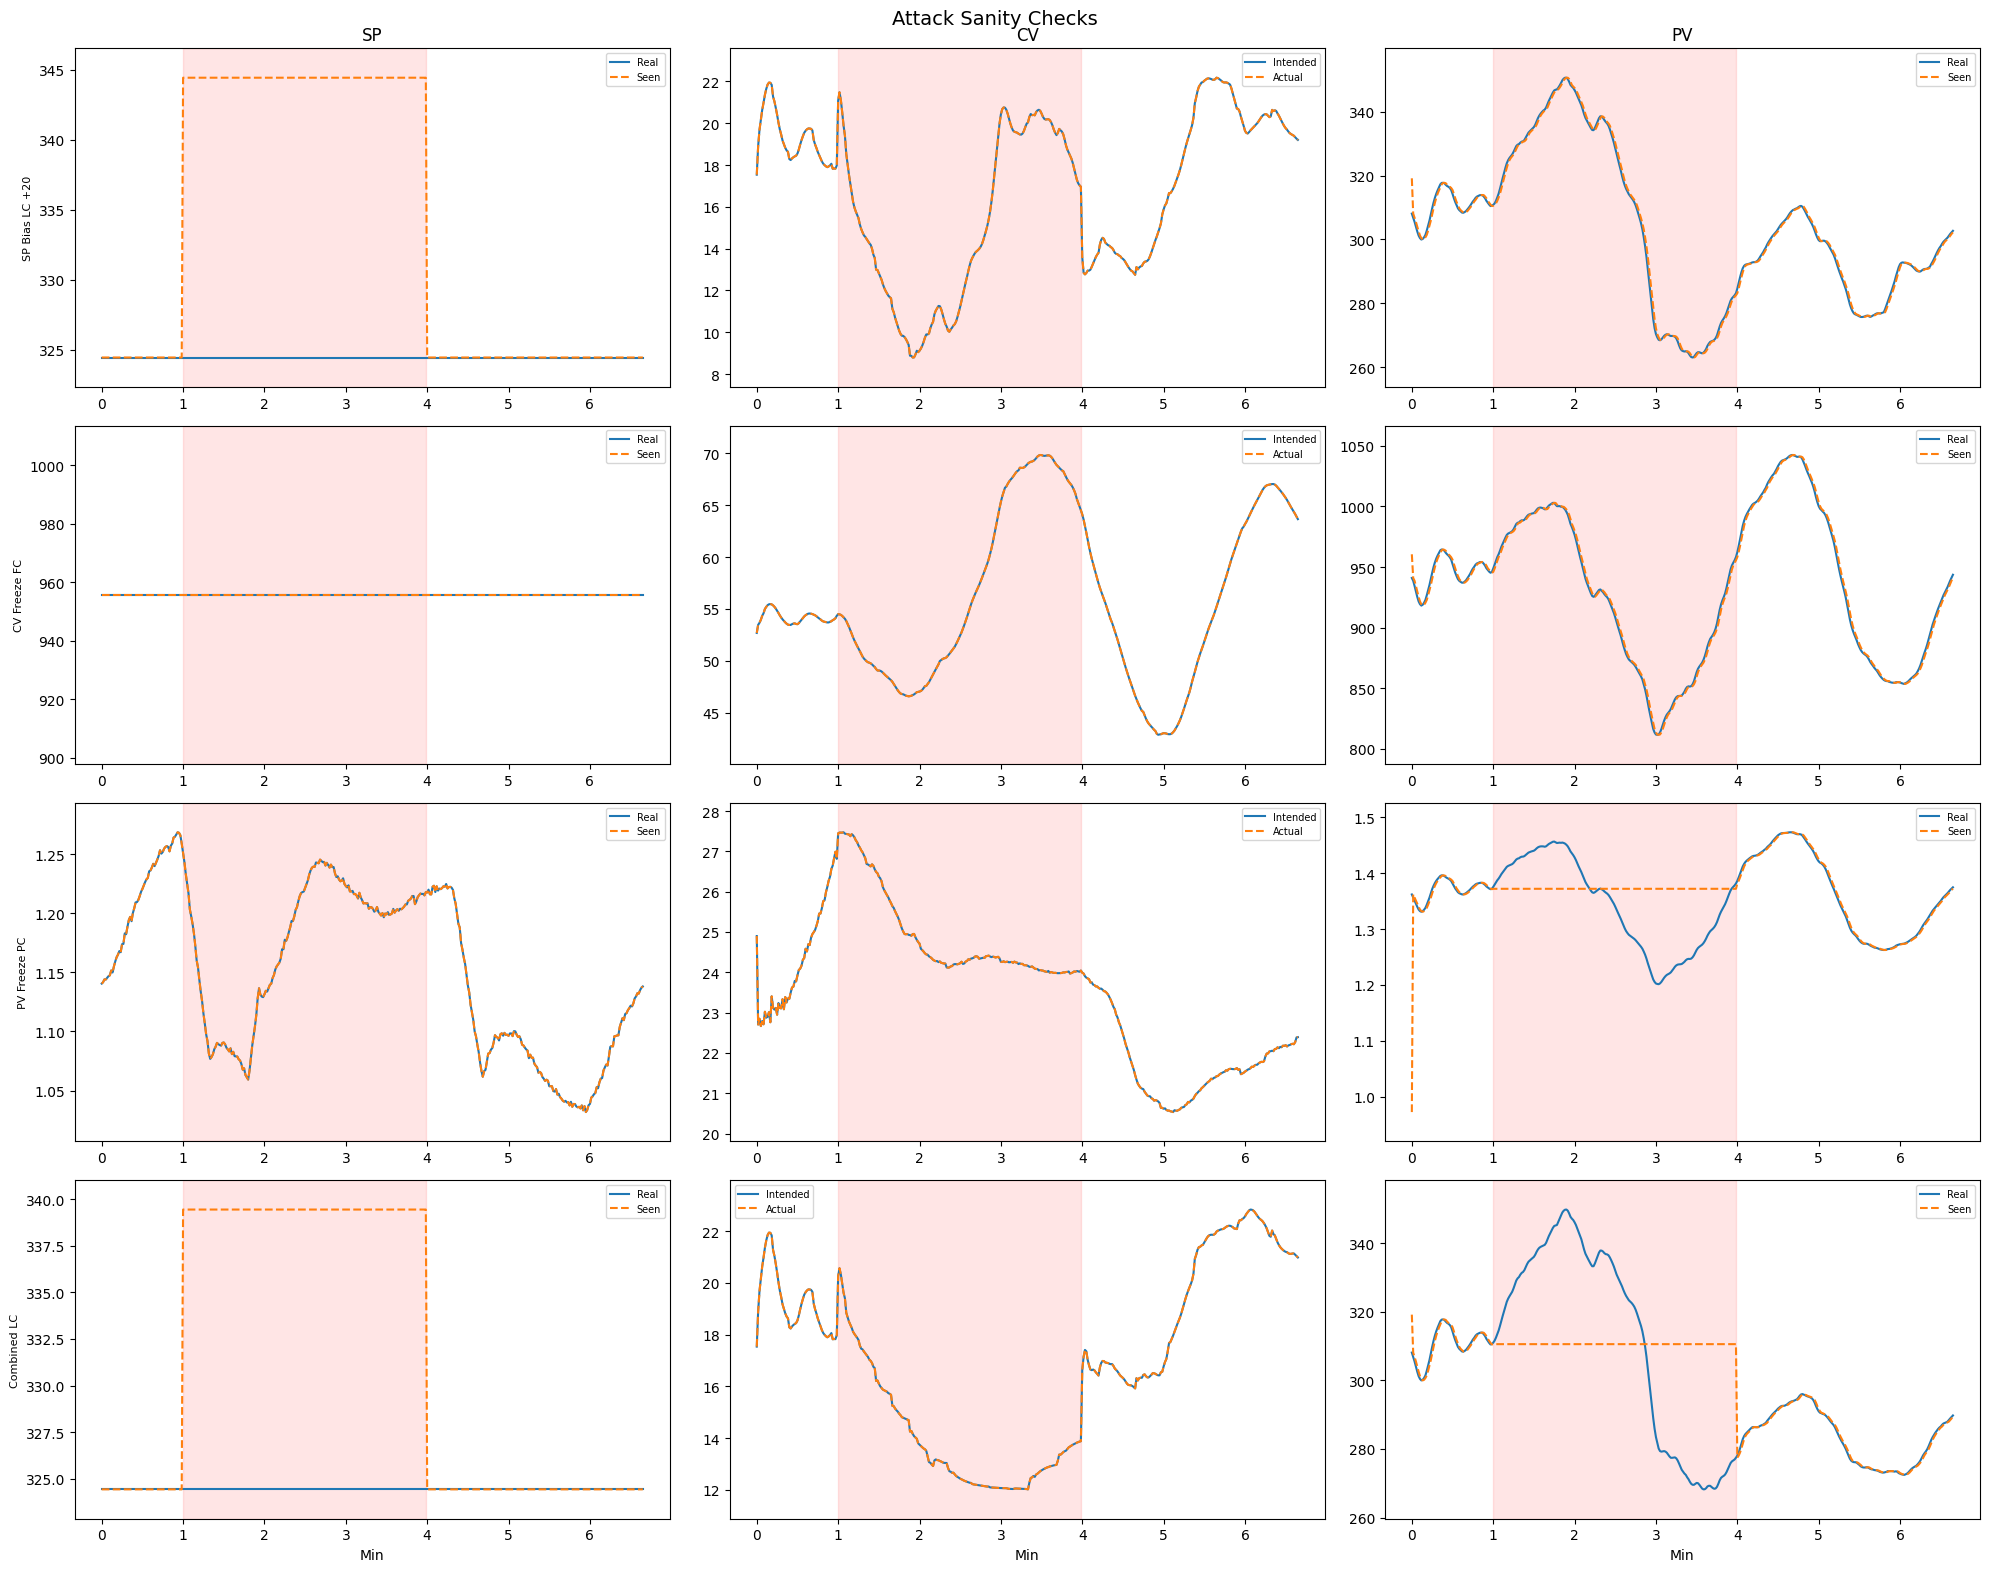


✓ Attack catalog ready


In [40]:
print("ATTACK SANITY CHECKS")
asi = mw+1000; adur=400
tests = [
    ("SP Bias LC +20", [AttackSpec('LC','SP',AttackType.BIAS,60,180,magnitude=20)], 'LC'),
    ("CV Freeze FC", [AttackSpec('FC','CV',AttackType.FREEZE,60,180)], 'FC'),
    ("PV Freeze PC", [AttackSpec('PC','PV',AttackType.FREEZE,60,180)], 'PC'),
    ("Combined LC", [AttackSpec('LC','SP',AttackType.BIAS,60,180,magnitude=15),
                     AttackSpec('LC','PV',AttackType.FREEZE,60,180)], 'LC'),
]
fig, axes = plt.subplots(len(tests),3,figsize=(20,4*len(tests)))
fig.suptitle('Attack Sanity Checks', fontsize=14)
for row,(title,specs,ln) in enumerate(tests):
    print(f"\n  {title}...")
    da = run_attack_sim(df_val, asi, adur, specs, CONFIG.W_controller, CONFIG.W_plant)
    t = da['time'].values/60
    for ci,(cs,ls) in enumerate([
        ([f'{ln}_SP_real',f'{ln}_SP_seen'],['Real','Seen']),
        ([f'{ln}_CV_intended',f'{ln}_CV_actual'],['Intended','Actual']),
        ([f'{ln}_PV_real',f'{ln}_PV_seen'],['Real','Seen'])]):
        ax=axes[row,ci]; ax.plot(t,da[cs[0]],label=ls[0]); ax.plot(t,da[cs[1]],label=ls[1],linestyle='--')
        ax.fill_between(t,0,1,where=da['attack_label']==1,alpha=0.1,color='red',transform=ax.get_xaxis_transform())
        ax.legend(fontsize=7)
        if row==0: ax.set_title(['SP','CV','PV'][ci])
    axes[row,0].set_ylabel(title,fontsize=8)
for ax in axes[-1]: ax.set_xlabel('Min')
plt.tight_layout(); plt.show()

print("\n✓ Attack catalog ready")
HAI_CATALOG = {
    'AP01': AttackSpec('PC','SP',AttackType.BIAS,100,300,magnitude=2.0),
    'AP14': AttackSpec('LC','SP',AttackType.BIAS,100,300,magnitude=50),
    'AP11': AttackSpec('FC','CV',AttackType.BIAS,100,300,magnitude=0.2),
    'AP16': AttackSpec('LC','CV',AttackType.BIAS,100,300,magnitude=0.15),
    'AP19': AttackSpec('TC','CV',AttackType.BIAS,100,300,magnitude=0.1),
    'AP23': AttackSpec('CC','CV',AttackType.BIAS,100,300,magnitude=5.0),
}

## Cell 14 — Summary Dashboard

In [41]:
print("=" * 60)
print("SURROGATE MODEL SUMMARY")
print("=" * 60)
print(f"\nW_ctrl={CONFIG.W_controller}, W_plant={CONFIG.W_plant}, Rollout={CONFIG.rollout_horizon}s")
print(f"Controller: {ctrl_types}")
print(f"Plant: {plant_type}")
print(f"\nGate 1a:")
for k,r in gate_1a_results.items(): print(f"  {'✓' if r['passed'] else '✗'} {k}: {r['nrmse']:.4f}")
print(f"Gate 1b:")
for k,r in gate_1b_results.items(): print(f"  {'✓' if r['passed'] else '✗'} {k}: {r['mean_nrmse']:.4f}")
print(f"Gate 3:")
for k,r in gate_3_results.items(): print(f"  {'✓' if r['passed'] else '✗'} {k}: {r['mean_nrmse']:.4f}")
ag = not gate_1a_failed and gate_1b_passed and gate_3_passed
print(f"\n{'✓ ALL GATES PASSED' if ag else '✗ SOME GATES FAILED'}")
print(f"\nCapabilities: Normal gen, SP/CV/PV attack injection, {len(HAI_CATALOG)} HAI scenarios")
print("Limitations: P1 only, no HAIEnd, fidelity degrades outside training envelope")

SURROGATE MODEL SUMMARY

W_ctrl=60, W_plant=120, Rollout=300s
Controller: {'PC': 'linear', 'LC': 'linear', 'FC': 'linear', 'TC': 'linear', 'CC': 'mlp'}
Plant: mlp

Gate 1a:
  ✓ PC: 0.0066
  ✓ LC: 0.0096
  ✓ FC: 0.0134
  ✓ TC: 0.0112
  ✗ CC: 0.3038
Gate 1b:
  ✓ P1_PIT01: 0.0049
  ✓ P1_LIT01: 0.0240
  ✓ P1_FT03Z: 0.0063
  ✗ P1_TIT01: 0.0892
  ✓ P1_TIT03: 0.0234
Gate 3:
  ✗ P1_PIT01: 0.1516
  ✗ P1_LIT01: 0.3264
  ✗ P1_FT03Z: 0.3173
  ✗ P1_TIT01: 0.2340
  ✗ P1_TIT03: 0.2527

✗ SOME GATES FAILED

Capabilities: Normal gen, SP/CV/PV attack injection, 6 HAI scenarios
Limitations: P1 only, no HAIEnd, fidelity degrades outside training envelope


In [42]:
import os, pandas as pd

HAIEND_DIR = '/content/drive/MyDrive/HAI_GNN/data/raw/haiend-23.05/'

# List files
print("=== HAIEnd FILES ===")
for f in sorted(os.listdir(HAIEND_DIR)):
    size = os.path.getsize(os.path.join(HAIEND_DIR, f)) / 1e6
    print(f"  {f} ({size:.1f} MB)")

# Inspect first file
df_end = pd.read_csv(os.path.join(HAIEND_DIR, 'end-train1.csv'), nrows=1000)
print(f"\nShape: {df_end.shape}")
print(f"\nAll {len(df_end.columns)} columns:")
for i, col in enumerate(df_end.columns):
    if df_end[col].dtype in ['float64','float32','int64']:
        std = df_end[col].std()
        tag = " *** CONSTANT ***" if std < 1e-10 else ""
        print(f"  {i:3d}. {col:<45s} [{df_end[col].min():.4f}, {df_end[col].max():.4f}]{tag}")
    else:
        print(f"  {i:3d}. {col:<45s} dtype={df_end[col].dtype}, sample={df_end[col].iloc[0]}")

# Hunt for the PC scaling column
print("\n=== PC SETPOINT CANDIDATES (1001 block) ===")
for col in df_end.columns:
    if '1001' in col:
        mn, mx = df_end[col].min(), df_end[col].max()
        print(f"  {col}: [{mn:.4f}, {mx:.4f}]")

=== HAIEnd FILES ===
  end-test1.csv (49.4 MB)
  end-test2.csv (209.7 MB)
  end-train1.csv (256.6 MB)
  end-train2.csv (266.9 MB)
  end-train3.csv (115.4 MB)
  end-train4.csv (180.2 MB)
  label-test1.csv (1.2 MB)
  label-test2.csv (4.5 MB)
  summary_label1.txt (0.0 MB)
  summary_label2.txt (0.0 MB)

Shape: (1000, 226)

All 226 columns:
    0. Timestamp                                     dtype=object, sample=2022-08-04 18:00:00
    1. DM-PP01-R                                     [0.0000, 0.0000] *** CONSTANT ***
    2. DM-FT01Z                                      [261.3818, 369.6289]
    3. DM-FT02Z                                      [3136.4478, 3186.4966]
    4. DM-FT03Z                                      [973.5488, 994.4229]
    5. 1001.2-OUT                                    [0.0000, 0.0000] *** CONSTANT ***
    6. 1001.7-OUT1                                   [0.0000, 0.0000] *** CONSTANT ***
    7. 1001.7-OUT2                                   [0.0000, 0.0000] *** CONSTANT 